In [96]:
import numpy as np
import pandas as pd
from datetime import datetime

## 1. Dataset preparation

### loading outfits dataframe

In [99]:
df_outfits = pd.read_csv("data/outfits.csv", sep=";")
df_outfits.head()

,id,name,description,group,owner,timeCreated,retailPrice,pricePerWeek,pricePerMonth,outfit_tags,tag_categories
0,outfit.fffdaa715c3646f8b1c0f04d549ff07e,Out of stock - Asymmetric Frilled Dress,"This fun, short dress features and asymmetric ...",group.50a586c78eb7626e294ba3bd07d12c79,o_00053,2017-12-30 11:28:01.000,4000.0,600.0,1200.0,"['Synthetic', 'Statement', 'Dresses', 'Metalli...","['Material', 'Occasion', 'Category', 'Details'..."
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,Yellow Shell Mellomholmene Blouse,This beautiful blouse features an adjustable n...,group.61ad2fcabb3e9197e3836376e6b67f2c,o_00577,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...","['Brand', 'Category', 'Seasons', 'Seasons', 'S..."
2,outfit.fff175b13ceb453f9928625491412ede,Kaula Dress Black,Kaula from Rodebjer is a fitted dress made in ...,group.37c2b59d63d3a9c2d58e07f532f71f7f,o_00336,2023-06-05 09:17:59.004,3100.0,930.0,1860.0,"['Black', 'Mini', 'M', 'Everyday', 'Multi Seas...","['Color', 'Length', 'Size', 'Occasion', 'Seaso..."
3,outfit.ffef9d7c292a48b69076d2df2e32352f,For sale - Jarvis Blouse,This wrap blouse has mid length sleeves and a ...,group.dfcaa57546b0b7a5e9eb204449b6cc1c,o_00030,2021-05-18 14:02:28.690,1500.0,590.0,1180.0,"['XS', 'Multi Season', 'Stylein', 'Tops', 'Cot...","['Size', 'Seasons', 'Brand', 'Category', 'Mate..."
4,outfit.ffeef842238f4dbdabc6c730a75aa2bd,Black Amber Pants,"Feel slack and nice dressed with this pant, ma...",group.ee297c977905eb21a123a4aea5fbb6d2,o_00602,2021-07-16 14:02:30.643,1200.0,590.0,1180.0,"['Cotton', 'Black', 'Everyday', 'Knitwear', 'L...","['Material', 'Color', 'Occasion', 'Category', ..."


In [100]:
print(df_outfits.columns.tolist())

['id', 'name', 'description', 'group', 'owner', 'timeCreated', 'retailPrice', 'pricePerWeek', 'pricePerMonth', 'outfit_tags', 'tag_categories']


### cleaning of outfits dataframe

In [102]:
df_outfits.columns = df_outfits.columns.str.strip()

In [103]:
df_outfits.drop_duplicates(inplace=True)

In [104]:
df_outfits = df_outfits.drop(columns=["name", "description", "group", "owner", "tag_categories"])

In [105]:
df_outfits.head()

,id,timeCreated,retailPrice,pricePerWeek,pricePerMonth,outfit_tags
0,outfit.fffdaa715c3646f8b1c0f04d549ff07e,2017-12-30 11:28:01.000,4000.0,600.0,1200.0,"['Synthetic', 'Statement', 'Dresses', 'Metalli..."
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat..."
2,outfit.fff175b13ceb453f9928625491412ede,2023-06-05 09:17:59.004,3100.0,930.0,1860.0,"['Black', 'Mini', 'M', 'Everyday', 'Multi Seas..."
3,outfit.ffef9d7c292a48b69076d2df2e32352f,2021-05-18 14:02:28.690,1500.0,590.0,1180.0,"['XS', 'Multi Season', 'Stylein', 'Tops', 'Cot..."
4,outfit.ffeef842238f4dbdabc6c730a75aa2bd,2021-07-16 14:02:30.643,1200.0,590.0,1180.0,"['Cotton', 'Black', 'Everyday', 'Knitwear', 'L..."


In [106]:
df_outfits.isnull().sum()

id                  0
timeCreated         0
retailPrice      1160
pricePerWeek        0
pricePerMonth       0
outfit_tags         0
dtype: int64

### renaming to outfit.id

In [108]:
df_outfits_renamed = df_outfits.rename(columns={'id': 'outfit.id'})

### loading user_activity dataframe

In [110]:
df_user_activity = pd.read_csv("data/user_activity_triplets.csv", sep = ";")
df_user_activity.head()

,customer.id,outfit.id,rentalPeriod.start,rentalPeriod.end
0,3448,outfit.5c081909537b42239e465d2d615c705f,2023-03-26,2023-04-25
1,2924,outfit.c34969dd8b334064aa90bfb60c8ec308,2023-03-27,2023-04-26
2,2924,outfit.aef4cc93eebf40ca8820790deb7a8323,2023-01-27,2023-02-26
3,1128,outfit.3de5df48a14b4a9aba6d8e41d11e9351,2021-11-16,2021-12-15
4,1128,outfit.0eaa358af14e469894062591bd42f38b,2021-10-11,2021-11-11


### cleaning of user_activity

In [112]:
df_user_activity.columns = df_user_activity.columns.str.strip()

In [113]:
df_user_activity.head()

,customer.id,outfit.id,rentalPeriod.start,rentalPeriod.end
0,3448,outfit.5c081909537b42239e465d2d615c705f,2023-03-26,2023-04-25
1,2924,outfit.c34969dd8b334064aa90bfb60c8ec308,2023-03-27,2023-04-26
2,2924,outfit.aef4cc93eebf40ca8820790deb7a8323,2023-01-27,2023-02-26
3,1128,outfit.3de5df48a14b4a9aba6d8e41d11e9351,2021-11-16,2021-12-15
4,1128,outfit.0eaa358af14e469894062591bd42f38b,2021-10-11,2021-11-11


In [114]:
df_user_activity.isnull().sum()

customer.id           0
outfit.id             0
rentalPeriod.start    0
rentalPeriod.end      0
dtype: int64

In [115]:
print(df_user_activity.shape)

(64419, 4)


### new dataframe with outfit_tags

In [117]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Convert string to list
df_outfits["outfit_tags"] = df_outfits["outfit_tags"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Multi-label binarization
mlb = MultiLabelBinarizer()
tags_encoded = mlb.fit_transform(df_outfits["outfit_tags"])

# Make a dataframe with outfit.id as index
df_tags = pd.DataFrame(tags_encoded, columns=[f"tag_{t.lower()}" for t in mlb.classes_])
df_tags["outfit.id"] = df_outfits["id"].values  # keep ID for merging when needed


# Merge rentals with tags
user_tags = df_user_activity.merge(df_tags, left_on="outfit.id", right_on="outfit.id", how="left")

# Group by user and sum tags → how many times each user rented an item with that tag
user_tags_agg = user_tags.groupby("customer.id").sum().reset_index()

#this is to be used when needed as tags are quite messy

# Identify tag columns
tag_cols = [c for c in df_tags.columns if c.startswith("tag_")]

# Merge rentals with tags
user_tags = df_user_activity.merge(df_tags, left_on="outfit.id", right_on="outfit.id", how="left")

#Aggregation of outfit tags, remember this is a separate data frame!!
# Group by user and sum only tag columns
user_tags_agg = user_tags.groupby("customer.id")[tag_cols].sum().reset_index()

user_tags_agg["tag_diversity"] = (user_tags_agg[tag_cols] > 0).sum(axis=1)

user_tags_agg.head()

,customer.id,tag_& other stories,tag_2love tony cohen,tag_2ndday,tag_3.1 philip lim,tag_36,tag_37,tag_38,tag_39,tag_3xl,...,tag_zetterberg,tag_zimmermann,tag_zizzi,tag_zoherberger,tag_zoul,tag_bymagmalou,tag_bytimo,tag_mbym,tag_me_cecilie,tag_diversity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
1,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,67
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,75
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,16
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,37


### merging outfits with user_activity on outfit.id

In [119]:
merged_df = pd.merge(df_outfits_renamed, df_user_activity, on='outfit.id', how='inner')

In [120]:
merged_df.head()

,outfit.id,timeCreated,retailPrice,pricePerWeek,pricePerMonth,outfit_tags,customer.id,rentalPeriod.start,rentalPeriod.end
0,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",1735,2023-08-17,2023-09-16
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",1382,2021-08-26,2021-09-27
2,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",5560,2022-03-16,2022-04-15
3,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",1382,2021-06-28,2021-07-26
4,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,2021-06-07 12:07:22.921,1300.0,590.0,1180.0,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2739,2023-06-21,2023-07-20


In [121]:
merged_df["rental_start"] = pd.to_datetime(merged_df["rentalPeriod.start"], format="%Y-%m-%d", errors="coerce")
merged_df["rental_end"]   = pd.to_datetime(merged_df["rentalPeriod.end"],   format="%Y-%m-%d", errors="coerce")
merged_df["rental_duration_days"] = (merged_df["rental_end"] - merged_df["rental_start"]).dt.days

In [122]:
merged_df[["customer.id", "outfit.id","outfit_tags", "timeCreated", "retailPrice", "pricePerWeek", "pricePerMonth", "rental_start", "rental_end", "rental_duration_days"]].head()

,customer.id,outfit.id,outfit_tags,timeCreated,retailPrice,pricePerWeek,pricePerMonth,rental_start,rental_end,rental_duration_days
0,1735,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2021-06-07 12:07:22.921,1300.0,590.0,1180.0,2023-08-17,2023-09-16,30
1,1382,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2021-06-07 12:07:22.921,1300.0,590.0,1180.0,2021-08-26,2021-09-27,32
2,5560,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2021-06-07 12:07:22.921,1300.0,590.0,1180.0,2022-03-16,2022-04-15,30
3,1382,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2021-06-07 12:07:22.921,1300.0,590.0,1180.0,2021-06-28,2021-07-26,28
4,2739,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,"['ILAG', 'Tops', 'Spring', 'Summer', 'M', 'Pat...",2021-06-07 12:07:22.921,1300.0,590.0,1180.0,2023-06-21,2023-07-20,29


In [221]:
merged_df.isnull().sum()

outfit.id                 0
timeCreated               0
retailPrice               0
pricePerWeek              0
pricePerMonth             0
outfit_tags               0
customer.id               0
rentalPeriod.start        0
rentalPeriod.end          0
rental_start              0
rental_end                0
rental_duration_days      0
days_since_last_rental    0
dtype: int64

In [223]:
merged_df = merged_df.fillna(0)

In [226]:
merged_df.isnull().sum()

outfit.id                 0
timeCreated               0
retailPrice               0
pricePerWeek              0
pricePerMonth             0
outfit_tags               0
customer.id               0
rentalPeriod.start        0
rentalPeriod.end          0
rental_start              0
rental_end                0
rental_duration_days      0
days_since_last_rental    0
dtype: int64

In [228]:
print(merged_df.shape)

(64419, 13)


## 2. Aggregation of Rentals per User
### Total Rentals

In [233]:
merged_df.groupby("customer.id").size()

customer.id
0         4
3        34
6        29
8         2
9         9
       ... 
7404      7
7409     46
7411    271
7412     13
7413      8
Length: 2293, dtype: int64

### Average Rental Duration

In [236]:
avg_duration_per_user = merged_df.groupby("customer.id")["rental_duration_days"].mean().reset_index()
avg_duration_per_user.rename(columns={"rental_duration_days": "avg_rental_duration"}, inplace=True)
print(avg_duration_per_user.head())

   customer.id  avg_rental_duration
0            0            29.250000
1            3            28.529412
2            6            32.689655
3            8            30.000000
4            9            29.666667


### Rental Frequency/Recency

In [239]:
# the latest rental_end as reference date
reference_date = merged_df["rental_end"].max()
print(reference_date)


2024-08-17 00:00:00


###  ~how long before the last dataset entry each user rented

In [242]:
recency = merged_df.groupby("customer.id")["rental_end"].max().reset_index()
recency["recency_days"] = (reference_date - recency["rental_end"]).dt.days

print(recency.head())



   customer.id rental_end  recency_days
0            0 2024-01-05           225
1            3 2022-01-31           929
2            6 2022-08-28           720
3            8 2022-08-25           723
4            9 2023-01-01           594


### ~no. of rentals in last 6 months (before the last entry)

In [245]:
six_months_ago = reference_date - pd.Timedelta(days=180)


recent_rentals = merged_df[merged_df["rental_start"] >= six_months_ago]
recent_rentals_count = recent_rentals.groupby("customer.id").size().reset_index(name="rentals_last_6_months")

print(recent_rentals_count.head())


   customer.id  rentals_last_6_months
0           46                     28
1           63                      8
2           73                     25
3           92                      4
4           95                      7


### ~average no. of days between rentals; lower means frequent renter

In [292]:
merged_df = merged_df.sort_values(["customer.id", "rental_start"])

merged_df["days_since_last_rental"] = merged_df.groupby("customer.id")["rental_start"].diff().dt.days

rental_frequency = merged_df.groupby("customer.id")["days_since_last_rental"].mean().reset_index()
rental_frequency.rename(columns={"days_since_last_rental": "avg_gap_days"}, inplace=True)

print(rental_frequency.head())
rental_frequency.fillna(0, inplace=True)
rental_frequency.isnull().sum()


   customer.id  avg_gap_days
0            0      4.666667
1            3      4.666667
2            6     12.071429
3            8      0.000000
4            9     11.375000


customer.id     0
avg_gap_days    0
dtype: int64

### ~recency; days since last rental

In [294]:
today = pd.Timestamp.today()

recency = merged_df.groupby("customer.id")["rental_end"].max().reset_index()
recency["recency_days"] = (today - recency["rental_end"]).dt.days

print(recency.head())


   customer.id rental_end  recency_days
0            0 2024-01-05           601
1            3 2022-01-31          1305
2            6 2022-08-28          1096
3            8 2022-08-25          1099
4            9 2023-01-01           970


In [296]:
user_features = merged_df.groupby("customer.id").agg(
    total_rentals=("rental_duration_days", "count"),
    avg_duration=("rental_duration_days", "mean")
).reset_index()

user_features = user_features.merge(rental_frequency, on="customer.id")
user_features = user_features.merge(recency[["customer.id", "recency_days"]], on="customer.id")

print(user_features.head())


   customer.id  total_rentals  avg_duration  avg_gap_days  recency_days
0            0              4     29.250000      4.666667           601
1            3             34     28.529412      4.666667          1305
2            6             29     32.689655     12.071429          1096
3            8              2     30.000000      0.000000          1099
4            9              9     29.666667     11.375000           970


### Aggregating tag features per user

In [299]:
user_tags = df_user_activity.merge(df_tags, left_on="outfit.id", right_on="outfit.id", how="left")
tag_cols = [c for c in df_tags.columns if c.startswith("tag_")]

user_tags_agg = user_tags.groupby("customer.id")[tag_cols].sum().reset_index()

# Tag diversity
user_tags_agg["tag_diversity"] = (user_tags_agg[tag_cols] > 0).sum(axis=1)

# Merge tag features with numeric features
user_features = user_features.merge(user_tags_agg, on="customer.id", how="left")

In [300]:
print(user_features.head())

   customer.id  total_rentals  avg_duration  avg_gap_days  recency_days  \
0            0              4     29.250000      4.666667           601   
1            3             34     28.529412      4.666667          1305   
2            6             29     32.689655     12.071429          1096   
3            8              2     30.000000      0.000000          1099   
4            9              9     29.666667     11.375000           970   

   tag_& other stories  tag_2love tony cohen  tag_2ndday  tag_3.1 philip lim  \
0                    0                     0           0                   0   
1                    0                     0           0                   0   
2                    0                     0           0                   0   
3                    0                     0           0                   0   
4                    0                     0           0                   0   

   tag_36  ...  tag_zetterberg  tag_zimmermann  tag_zizzi  tag_zoher

## K-means Clustering

In [304]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ["total_rentals", "avg_duration", "avg_gap_days", "recency_days", "tag_diversity"]
X = user_features[features].fillna(0)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X_scaled.shape}")
print(f"Features used: {features}")

Data shape: (2293, 5)
Features used: ['total_rentals', 'avg_duration', 'avg_gap_days', 'recency_days', 'tag_diversity']


In [306]:
print(X.isna().sum())

total_rentals    0
avg_duration     0
avg_gap_days     0
recency_days     0
tag_diversity    0
dtype: int64


In [308]:
print(X.dtypes)


total_rentals      int64
avg_duration     float64
avg_gap_days     float64
recency_days       int64
tag_diversity      int64
dtype: object


### Determination of best fitted number of clusters


In [311]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

def evaluate_clusters(X_scaled, max_k=15):
    """Evaluate clusters using multiple methods"""
    
    K = range(2, max_k + 1)  # Start from 2 for silhouette score
    inertias = []
    silhouette_scores = []
    
    # Calculate metrics for each k
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    
    return K, inertias, silhouette_scores

In [313]:
K, inertias, silhouette_scores = evaluate_clusters(X_scaled, max_k=12)

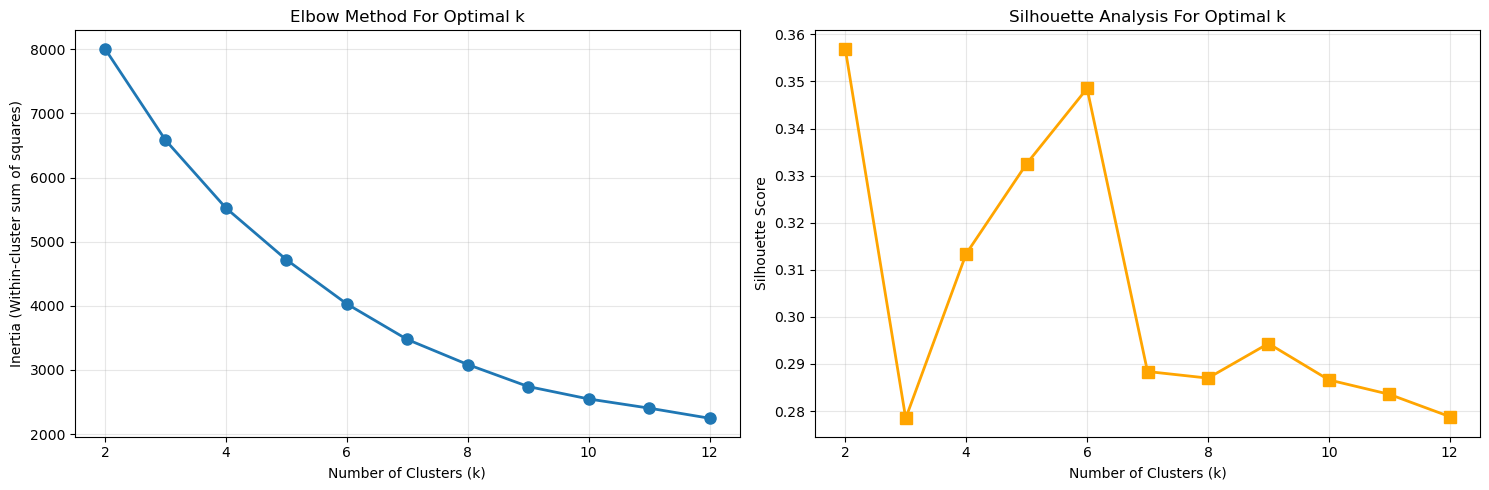

In [314]:
# Subplots for better visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#Plot 1: Elbow
ax1.plot(K, inertias, marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method For Optimal k')
ax1.grid(True, alpha=0.3)

#Plot 2: Silhouette Score
# * Silhouette Analysis measures how well-separated clusters are
ax2.plot(K, silhouette_scores, marker='s', color='orange', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis For Optimal k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [315]:
def find_elbow_point(inertias):
    """Find elbow point using rate of change"""
    differences = np.diff(inertias)
    differences2 = np.diff(differences)
    
    print("Rate of inertia decrease by k:")
    for i, diff in enumerate(differences, 2):
        print(f"k={i}: {diff:.1f}")
    
    print("\nSecond derivative (change in rate):")
    for i, diff2 in enumerate(differences2, 3):
        print(f"k={i}: {diff2:.1f}")
    
    # Find where second derivative is maximum (biggest change in slope)
    elbow_k = np.argmax(differences2) + 3
    return elbow_k

elbow_k = find_elbow_point(inertias)
best_silhouette_k = K[np.argmax(silhouette_scores)]

print(f"\n=== RECOMMENDATIONS ===")
print(f"Elbow method suggests: k = {elbow_k}")
print(f"Best silhouette score: k = {best_silhouette_k} (score: {max(silhouette_scores):.3f})")
print(f"Silhouette scores for k=4,5,6: {[silhouette_scores[i-2] for i in [4,5,6]]}")

Rate of inertia decrease by k:
k=2: -1423.4
k=3: -1058.7
k=4: -806.2
k=5: -689.4
k=6: -554.4
k=7: -390.6
k=8: -343.4
k=9: -193.5
k=10: -143.0
k=11: -158.0

Second derivative (change in rate):
k=3: 364.7
k=4: 252.4
k=5: 116.9
k=6: 134.9
k=7: 163.8
k=8: 47.2
k=9: 149.9
k=10: 50.5
k=11: -14.9

=== RECOMMENDATIONS ===
Elbow method suggests: k = 3
Best silhouette score: k = 2 (score: 0.357)
Silhouette scores for k=4,5,6: [0.3133955921754371, 0.33252083138014354, 0.3485212120535842]


In [316]:


if max(silhouette_scores) > 0.5:
    recommended_k = best_silhouette_k
    reason = "high silhouette score"
elif elbow_k in [4, 5, 6]:
    recommended_k = elbow_k
    reason = "clear elbow point"
else:
    # Choose k with best silhouette among 4,5,6
    candidates = [(k, silhouette_scores[k-2]) for k in [4,5,6] if k-2 < len(silhouette_scores)]
    recommended_k = max(candidates, key=lambda x: x[1])[0]
    reason = "best among business-viable options (4-6 clusters)"

print(f"\n🎯 FINAL RECOMMENDATION: k = {recommended_k} ({reason})")


🎯 FINAL RECOMMENDATION: k = 6 (best among business-viable options (4-6 clusters))


### Clustering

=== APPLYING K-MEANS CLUSTERING (k=6) ===
✅ Clustering completed with k=6
Cluster distribution:
  Cluster 0: 1191 users (51.9%)
  Cluster 1: 161 users (7.0%)
  Cluster 2: 762 users (33.2%)
  Cluster 3: 58 users (2.5%)
  Cluster 4: 44 users (1.9%)
  Cluster 5: 77 users (3.4%)

=== CLUSTER CHARACTERISTICS ===
         total_rentals  avg_duration  avg_gap_days  recency_days  \
cluster                                                            
0                 8.59         29.74          7.52       1219.24   
1               148.27         31.11          7.23        475.46   
2                37.47         30.57         12.33        666.35   
3                 8.71         30.22         70.64        842.33   
4                15.93         52.07         14.53       1118.52   
5                 7.18         13.48          2.58       1642.05   

         tag_diversity  
cluster                 
0                34.49  
1               124.66  
2                72.67  
3                37.4

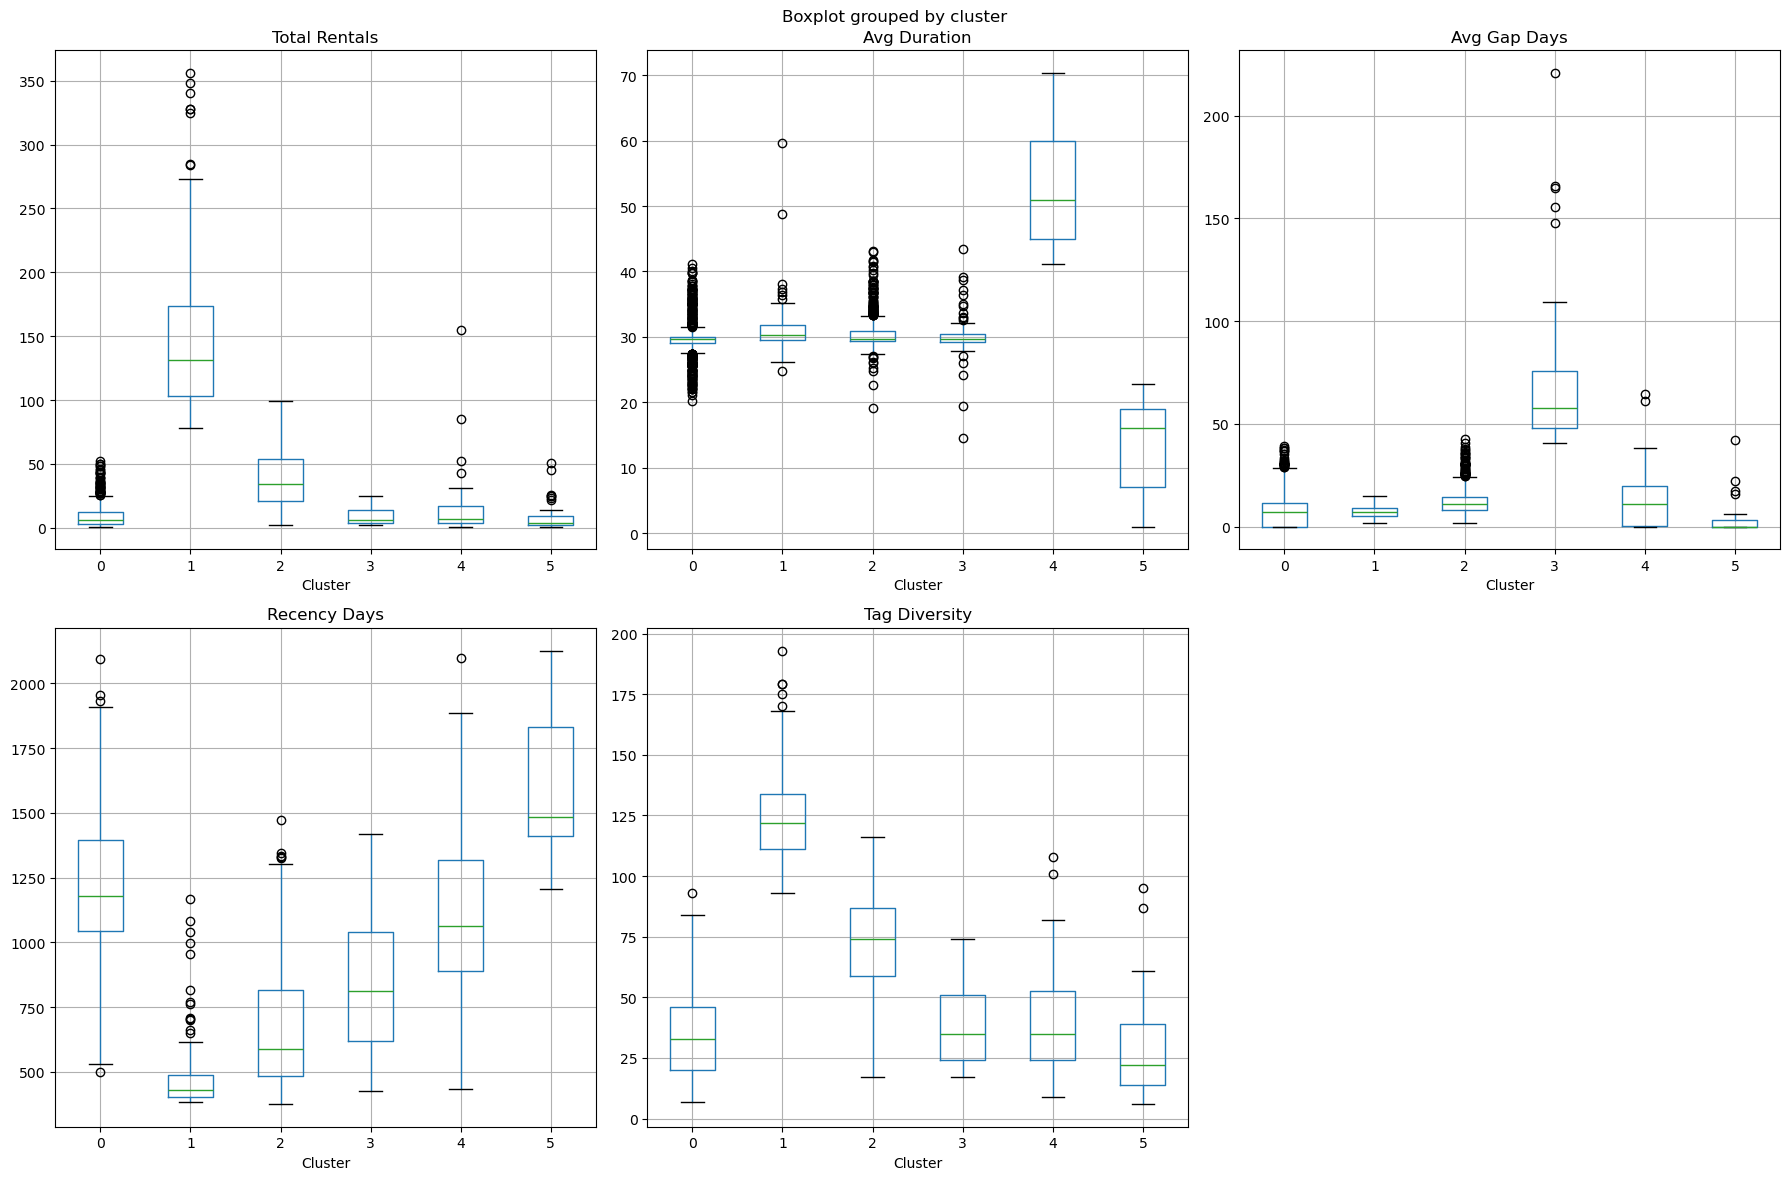

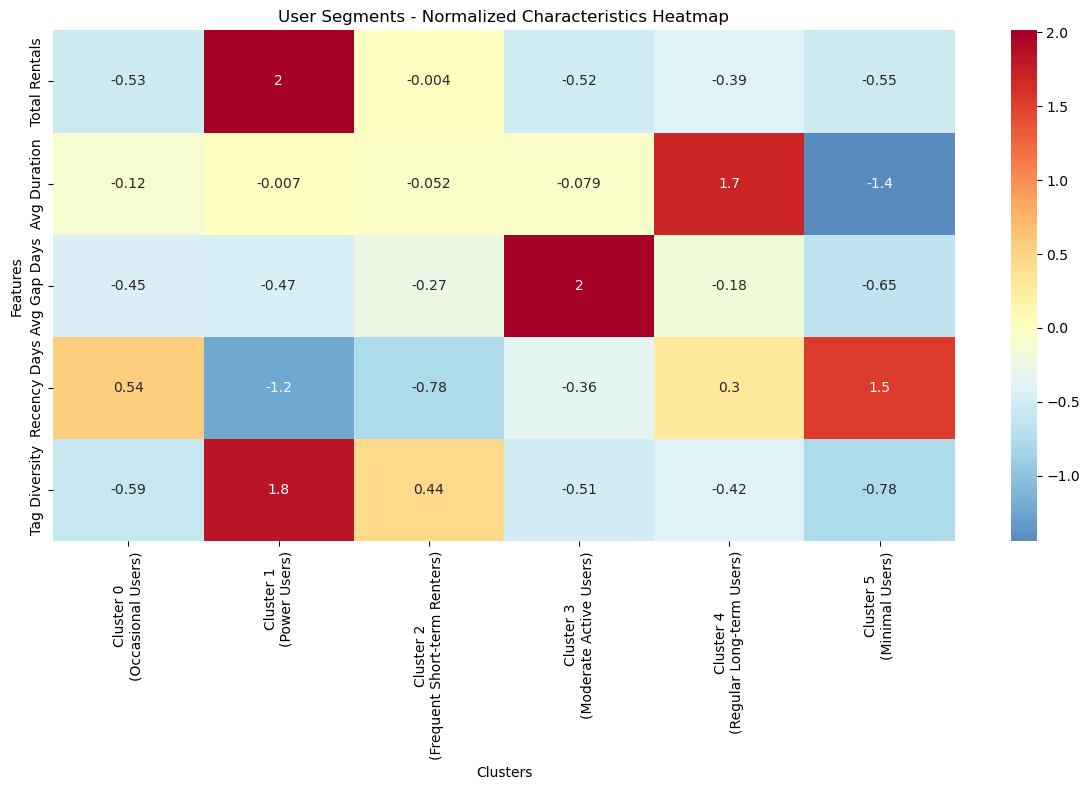


✅ USER SEGMENTATION COMPLETE!
📋 Your user_features dataframe now includes:
   • 'cluster': Numeric cluster ID (0-5)
   • 'segment_name': Business-friendly segment names

🎯 Next steps: Use these segments for targeted marketing, pricing strategies, and product recommendations!


In [318]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# K-means with k=6 (already determined as optimal)
print("=== APPLYING K-MEANS CLUSTERING (k=6) ===")

# Use the same features and scaling from analysis
segmentation_features = ["total_rentals", "avg_duration", "avg_gap_days", "recency_days", "tag_diversity"]
X = user_features[segmentation_features].fillna(0)

# Standardize features (using same scaler from  analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means with k=6
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
user_features['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✅ Clustering completed with k=6")
print(f"Cluster distribution:")
cluster_counts = user_features['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(user_features)) * 100
    print(f"  Cluster {cluster}: {count} users ({pct:.1f}%)")

# Analyze each cluster's characteristics
print(f"\n=== CLUSTER CHARACTERISTICS ===")
cluster_stats = user_features.groupby('cluster')[segmentation_features].mean().round(2)
print(cluster_stats)

# Create business-friendly segment names based on cluster characteristics
def create_segment_names(df, features):
    """Create 6 distinct segments focusing on rental frequency patterns"""
    
    cluster_profiles = df.groupby('cluster')[features].mean()
    overall_stats = df[features].describe()
    
    segment_names = {}
    cluster_characteristics = {}
    
    # Analyze each cluster's key characteristics
    for cluster in cluster_profiles.index:
        profile = cluster_profiles.loc[cluster]
        
        # Frequency levels
        if profile['total_rentals'] > overall_stats.loc['75%', 'total_rentals']:
            freq_level = "High"
        elif profile['total_rentals'] > overall_stats.loc['50%', 'total_rentals']:
            freq_level = "Mid"
        else:
            freq_level = "Low"
        
        # Duration preference
        if profile['avg_duration'] > overall_stats.loc['75%', 'avg_duration']:
            duration_pref = "Long"
        elif profile['avg_duration'] < overall_stats.loc['25%', 'avg_duration']:
            duration_pref = "Short"
        else:
            duration_pref = "Medium"
        
        # Activity recency
        if profile['recency_days'] > overall_stats.loc['75%', 'recency_days']:
            activity_status = "Inactive"
        elif profile['recency_days'] < overall_stats.loc['25%', 'recency_days']:
            activity_status = "Recent"
        else:
            activity_status = "Moderate"
        
        cluster_characteristics[cluster] = {
            'freq_level': freq_level,
            'duration_pref': duration_pref,
            'activity_status': activity_status,
            'total_rentals': profile['total_rentals'],
            'avg_duration': profile['avg_duration'],
            'recency_days': profile['recency_days']
        }
    
    # Sort clusters by rental frequency to assign names systematically
    sorted_clusters = sorted(cluster_characteristics.keys(), 
                           key=lambda x: cluster_characteristics[x]['total_rentals'], 
                           reverse=True)
    
    # Assign names based on frequency ranking and key characteristics
    for i, cluster in enumerate(sorted_clusters):
        char = cluster_characteristics[cluster]
        
        if i == 0:  # Highest frequency cluster
            if char['activity_status'] == "Recent":
                name = "Power Users"
            else:
                name = "Heavy Users (Declining)"
                
        elif i == 1:  # Second highest frequency
            if char['duration_pref'] == "Long":
                name = "Frequent Long-term Renters"
            else:
                name = "Frequent Short-term Renters"
                
        elif i == 2:  # Third highest (upper mid-tier)
            if char['duration_pref'] == "Long":
                name = "Regular Long-term Users"
            else:
                name = "Regular Active Users"
                
        elif i == 3:  # Fourth (lower mid-tier)
            if char['activity_status'] == "Inactive":
                name = "Moderate Users (Inactive)"
            else:
                name = "Moderate Active Users"
                
        elif i == 4:  # Fifth (low frequency)
            if char['activity_status'] == "Inactive":
                name = "Low-frequency Users (Dormant)"
            else:
                name = "Occasional Users"
                
        else:  # Lowest frequency cluster
            if char['total_rentals'] <= 1:
                name = "One-time/Trial Users"
            else:
                name = "Minimal Users"
        
        segment_names[cluster] = name
    
    return segment_names

# Apply segment names
segment_names = create_segment_names(user_features, segmentation_features)
user_features['segment_name'] = user_features['cluster'].map(segment_names)

print(f"\n=== BUSINESS SEGMENT NAMES ===")
for cluster in sorted(segment_names.keys()):
    count = len(user_features[user_features['cluster'] == cluster])
    pct = (count / len(user_features)) * 100
    print(f"Cluster {cluster}: '{segment_names[cluster]}' ({count} users, {pct:.1f}%)")

# Detailed segment analysis with business metrics
print(f"\n=== DETAILED SEGMENT ANALYSIS ===")
segment_summary = user_features.groupby(['cluster', 'segment_name']).agg({
    'total_rentals': ['count', 'mean', 'std'],
    'avg_duration': ['mean', 'std'],
    'avg_gap_days': ['mean', 'std'],
    'recency_days': ['mean', 'std'],
    'tag_diversity': ['mean', 'std']
}).round(2)

print("Segment Summary Statistics:")
print(segment_summary)

# Business insights for each segment
print(f"\n=== BUSINESS INSIGHTS BY SEGMENT ===")
for cluster in sorted(segment_names.keys()):
    segment_data = user_features[user_features['cluster'] == cluster]
    name = segment_names[cluster]
    
    avg_rentals = segment_data['total_rentals'].mean()
    avg_duration = segment_data['avg_duration'].mean()
    avg_recency = segment_data['recency_days'].mean()
    avg_diversity = segment_data['tag_diversity'].mean()
    
    print(f"\n📊 {name.upper()} (Cluster {cluster}):")
    print(f"   • Average rentals per user: {avg_rentals:.1f}")
    print(f"   • Average rental duration: {avg_duration:.1f} days")
    print(f"   • Days since last rental: {avg_recency:.1f}")
    print(f"   • Tag diversity score: {avg_diversity:.1f}")
    
    # Business recommendations
    if "Power" in name:
        print(f"   💡 Strategy: VIP treatment, loyalty rewards, early access to new items")
    elif "Inactive" in name or "Churned" in name:
        print(f"   💡 Strategy: Reactivation campaigns, win-back offers")
    elif "New" in name or "Trial" in name:
        print(f"   💡 Strategy: Onboarding support, first-time user incentives")
    elif "Long-term" in name:
        print(f"   💡 Strategy: Extended rental discounts, seasonal collections")
    elif "Frequent" in name and "Short-term" in name:
        print(f"   💡 Strategy: Subscription models, quick-change inventory")
    else:
        print(f"   💡 Strategy: Engagement campaigns, personalized recommendations")

# Visualization of segments
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('User Segments - Key Characteristics (k=6)', fontsize=16)

features_to_plot = segmentation_features + ['cluster']
plot_features = segmentation_features

for i, feature in enumerate(plot_features):
    row = i // 3
    col = i % 3
    
    # Box plot for each feature by cluster
    user_features.boxplot(column=feature, by='cluster', ax=axes[row, col])
    axes[row, col].set_title(f'{feature.replace("_", " ").title()}')
    axes[row, col].set_xlabel('Cluster')

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

# Create a heatmap of segment characteristics
plt.figure(figsize=(12, 8))
cluster_profiles = user_features.groupby('cluster')[segmentation_features].mean()

# Normalize for better visualization (z-score)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

sns.heatmap(cluster_profiles_norm.T, 
            annot=True, 
            cmap='RdYlBu_r', 
            center=0,
            xticklabels=[f"Cluster {i}\n({segment_names[i]})" for i in cluster_profiles.index],
            yticklabels=[f.replace('_', ' ').title() for f in segmentation_features])
plt.title('User Segments - Normalized Characteristics Heatmap')
plt.ylabel('Features')
plt.xlabel('Clusters')
plt.tight_layout()
plt.show()

print(f"\n✅ USER SEGMENTATION COMPLETE!")
print(f"📋 Your user_features dataframe now includes:")
print(f"   • 'cluster': Numeric cluster ID (0-5)")
print(f"   • 'segment_name': Business-friendly segment names")
print(f"\n🎯 Next steps: Use these segments for targeted marketing, pricing strategies, and product recommendations!")

## Correlation check

=== STEP 1: CORRELATION ANALYSIS ===

Correlation Matrix:
               total_rentals  avg_duration  avg_gap_days  recency_days  \
total_rentals          1.000         0.109        -0.050        -0.469   
avg_duration           0.109         1.000         0.121        -0.205   
avg_gap_days          -0.050         0.121         1.000        -0.170   
recency_days          -0.469        -0.205        -0.170         1.000   
tag_diversity          0.871         0.143         0.037        -0.534   

               tag_diversity  
total_rentals          0.871  
avg_duration           0.143  
avg_gap_days           0.037  
recency_days          -0.534  
tag_diversity          1.000  

=== STRONG CORRELATIONS (|r| > 0.7) ===
• total_rentals ↔ tag_diversity: 0.871

=== MODERATE CORRELATIONS (0.3 < |r| < 0.7) ===
• total_rentals ↔ recency_days: -0.469
• recency_days ↔ tag_diversity: -0.534


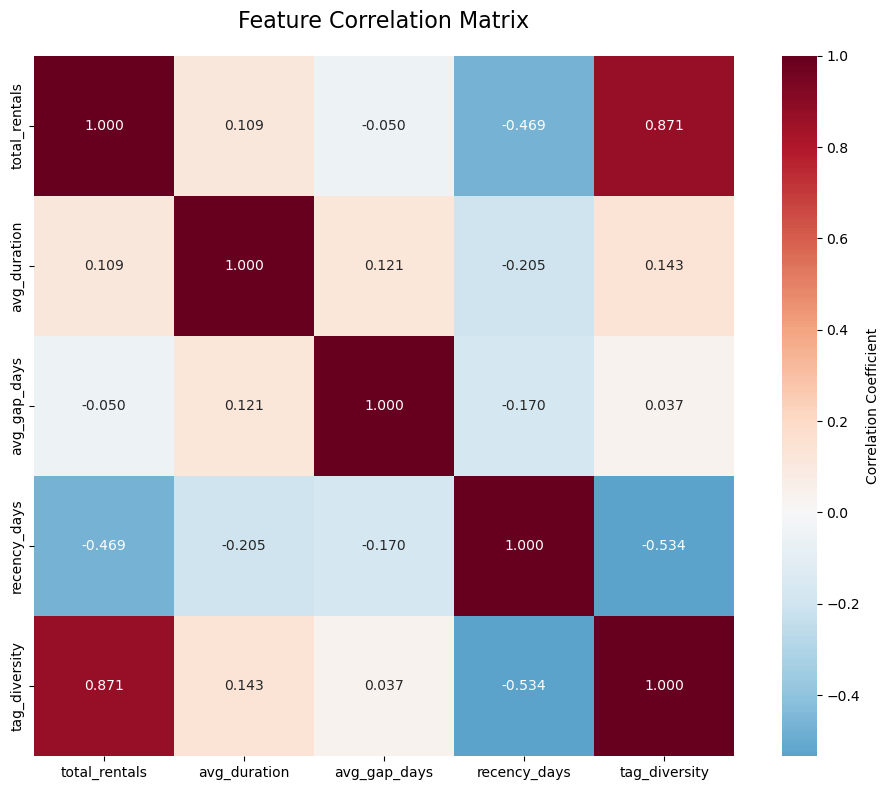


=== DATA CLEANING FOR ANALYSIS ===
Data quality after cleaning:
  total_rentals: NaN=0, Inf=0
  avg_duration: NaN=0, Inf=0
  avg_gap_days: NaN=0, Inf=0
  recency_days: NaN=0, Inf=0
  tag_diversity: NaN=0, Inf=0

=== MULTICOLLINEARITY CHECK (VIF) ===
VIF > 10: High multicollinearity
VIF 5-10: Moderate multicollinearity
VIF < 5: Low multicollinearity
• total_rentals: VIF = 6.07
• avg_duration: VIF = 13.72
• avg_gap_days: VIF = 1.72
• recency_days: VIF = 6.16
• tag_diversity: VIF = 15.22

⚠️  High multicollinearity detected: avg_duration, tag_diversity


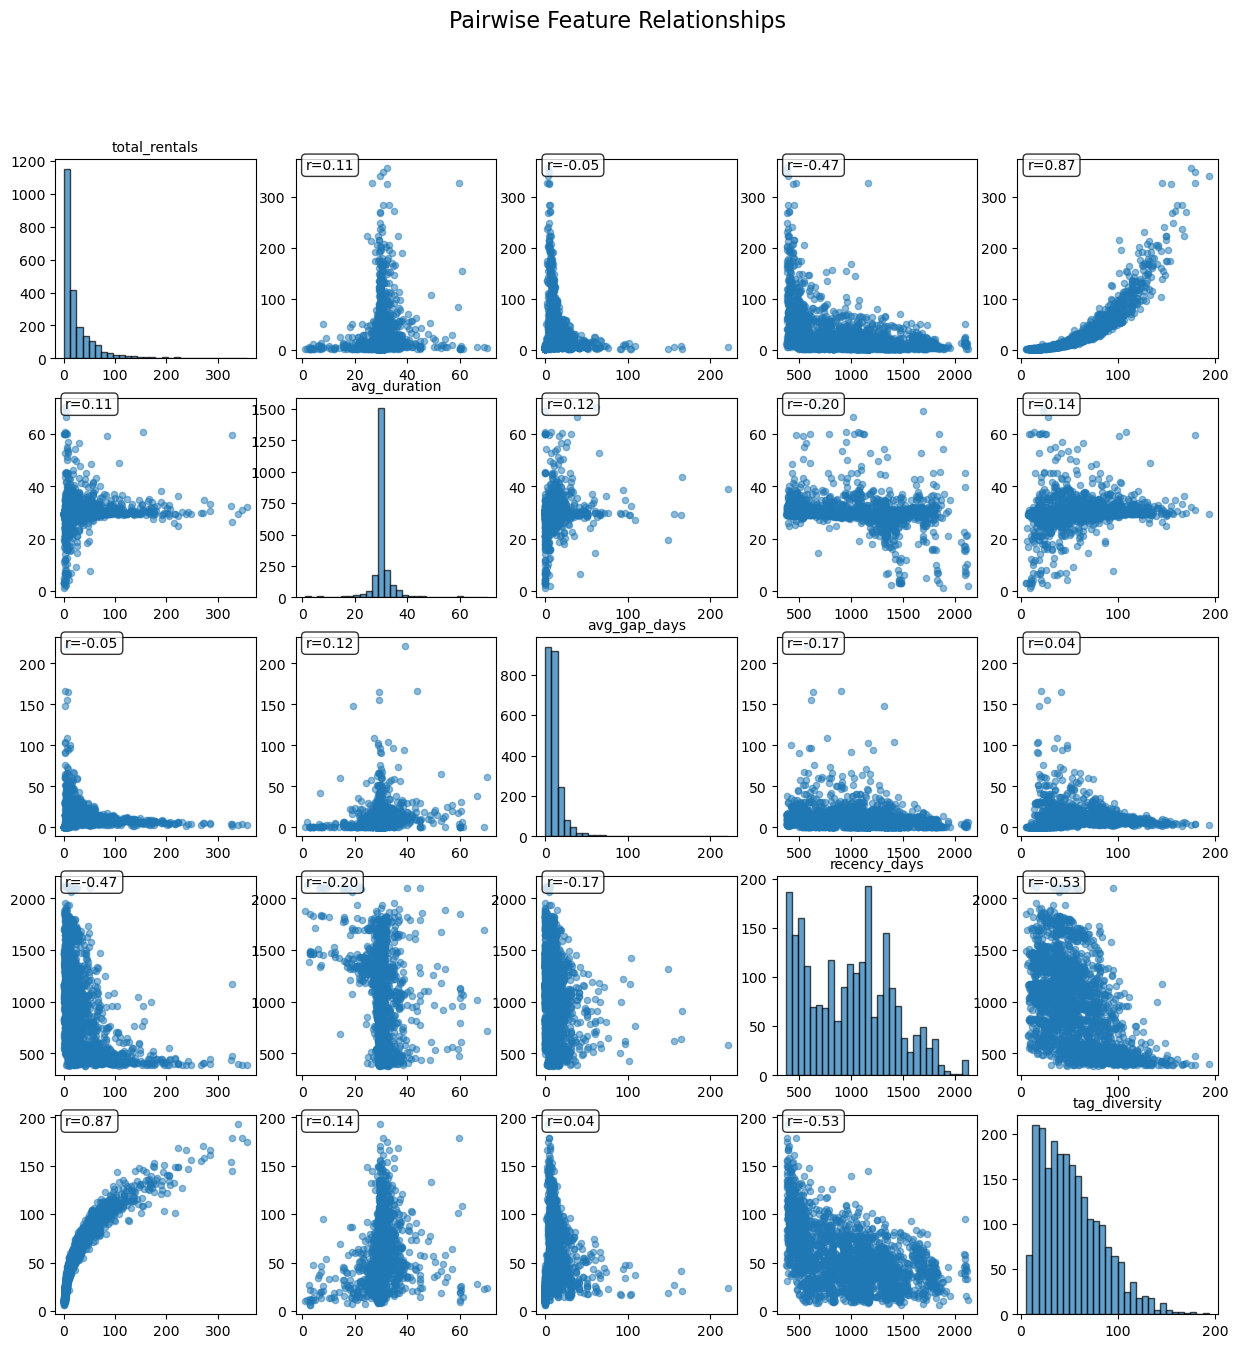

In [355]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=== STEP 1: CORRELATION ANALYSIS ===")

# Define original segmentation features
original_features = ["total_rentals", "avg_duration", "avg_gap_days", "recency_days", "tag_diversity"]

# Calculate correlation matrix
correlation_matrix = user_features[original_features].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Identify strong correlations (|r| > 0.7)
print("\n=== STRONG CORRELATIONS (|r| > 0.7) ===")
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            strong_correlations.append((feature1, feature2, corr_val))
            print(f"• {feature1} ↔ {feature2}: {corr_val:.3f}")

if not strong_correlations:
    print("• No strong correlations found")

# Identify moderate correlations (0.3 < |r| < 0.7)
print("\n=== MODERATE CORRELATIONS (0.3 < |r| < 0.7) ===")
moderate_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if 0.3 < abs(corr_val) < 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            moderate_correlations.append((feature1, feature2, corr_val))
            print(f"• {feature1} ↔ {feature2}: {corr_val:.3f}")

if not moderate_correlations:
    print("• No moderate correlations found")

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Pairwise scatter plots for visual correlation inspection
fig, axes = plt.subplots(len(segmentation_features), len(segmentation_features), 
                        figsize=(15, 15))
fig.suptitle('Pairwise Feature Relationships', fontsize=16)

for i, feature1 in enumerate(segmentation_features):
    for j, feature2 in enumerate(segmentation_features):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogram of the feature
            ax.hist(user_features[feature1], bins=30, alpha=0.7, edgecolor='black')
            ax.set_title(f'{feature1}', fontsize=10)
        else:
            # Off-diagonal: scatter plot
            ax.scatter(user_features[feature2], user_features[feature1], 
                      alpha=0.5, s=20)
            
            # Add correlation coefficient to plot
            corr_val = correlation_matrix.loc[feature1, feature2]
            ax.text(0.05, 0.95, f'r={corr_val:.2f}', 
                   transform=ax.transAxes, fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Clean data for statistical tests
print("\n=== DATA CLEANING FOR ANALYSIS ===")
clean_data = user_features[original_features].copy()
clean_data = clean_data.replace([np.inf, -np.inf], np.nan)
clean_data = clean_data.fillna(0)

print("Data quality after cleaning:")
for feature in original_features:
    feature_data = clean_data[feature]
    print(f"  {feature}: NaN={feature_data.isna().sum()}, Inf={np.isinf(feature_data).sum()}")

# VIF Analysis (Variance Inflation Factor)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    print("\n=== MULTICOLLINEARITY CHECK (VIF) ===")
    print("VIF > 10: High multicollinearity")
    print("VIF 5-10: Moderate multicollinearity")
    print("VIF < 5: Low multicollinearity")
    
    vif_results = []
    high_vif_features = []
    
    for i, feature in enumerate(original_features):
        try:
            vif = variance_inflation_factor(clean_data[original_features].values, i)
            vif_results.append((feature, vif))
            print(f"• {feature}: VIF = {vif:.2f}")
            
            if vif > 10:
                high_vif_features.append(feature)
        except Exception as e:
            print(f"• {feature}: VIF calculation failed")
    
    if high_vif_features:
        print(f"\n⚠️  High multicollinearity detected: {', '.join(high_vif_features)}")
    else:
        print("\n✅ No high multicollinearity detected")

except ImportError:
    print("\n⚠️  statsmodels not available - skipping VIF analysis")
    high_vif_features = []


## Feature selection

In [345]:
print("\n=== STEP 2: FEATURE SELECTION ===")

# Apply feature selection based on correlation and VIF analysis
features_to_remove = []

# Remove one feature from each strongly correlated pair
for feat1, feat2, corr in strong_correlations:
    if feat2 not in features_to_remove:  # Avoid removing both
        features_to_remove.append(feat2)
        print(f"Removing {feat2} due to strong correlation with {feat1} ({corr:.3f})")

# Remove high VIF features (if not already removed)
for feature in high_vif_features:
    if feature not in features_to_remove:
        features_to_remove.append(feature)
        print(f"Removing {feature} due to high VIF")

# Create final feature list
selected_features = [f for f in original_features if f not in features_to_remove]

print(f"\nFeature Selection Summary:")
print(f"• Original features ({len(original_features)}): {original_features}")
print(f"• Removed features ({len(features_to_remove)}): {features_to_remove}")
print(f"• Selected features ({len(selected_features)}): {selected_features}")


=== STEP 2: FEATURE SELECTION ===
Removing tag_diversity due to strong correlation with total_rentals (0.871)
Removing avg_duration due to high VIF

Feature Selection Summary:
• Original features (5): ['total_rentals', 'avg_duration', 'avg_gap_days', 'recency_days', 'tag_diversity']
• Removed features (2): ['tag_diversity', 'avg_duration']
• Selected features (3): ['total_rentals', 'avg_gap_days', 'recency_days']


## PCA Analysis

In [347]:
print("\n=== STEP 3: PCA ANALYSIS WITH MULTICOLLINEARITY-FIXED FEATURES ===")

# Prepare data for PCA
pca_data = user_features[selected_features].copy()
pca_data = pca_data.replace([np.inf, -np.inf], np.nan)
pca_data = pca_data.fillna(0)

print(f"\nPCA Input Data:")
print(f"• Shape: {pca_data.shape}")
print(f"• Features: {selected_features}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

# Perform full PCA analysis
pca_full = PCA()
pca_full.fit(X_scaled)

eigenvalues = pca_full.explained_variance_
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"\n=== EIGENVALUE ANALYSIS ===")
print("Component | Eigenvalue | Variance% | Cumulative% | Kaiser Decision")
print("-" * 65)

kaiser_components = 0
for i in range(len(eigenvalues)):
    eigenval = eigenvalues[i]
    var_pct = explained_variance_ratio[i] * 100
    cum_pct = cumulative_variance[i] * 100
    
    if eigenval >= 1.0:
        kaiser_decision = "RETAIN"
        kaiser_components += 1
    else:
        kaiser_decision = "drop"
    
    print(f"   PC{i+1:2d}    |   {eigenval:6.3f}   |   {var_pct:5.1f}%   |    {cum_pct:5.1f}%    |    {kaiser_decision}")

# Component selection criteria
var_80_components = np.argmax(cumulative_variance >= 0.80) + 1 if any(cumulative_variance >= 0.80) else len(cumulative_variance)
var_90_components = np.argmax(cumulative_variance >= 0.90) + 1 if any(cumulative_variance >= 0.90) else len(cumulative_variance)

print(f"\n=== COMPONENT SELECTION CRITERIA ===")
criteria_results = {
    'Kaiser Criterion (λ≥1)': kaiser_components,
    '80% Variance': var_80_components,
    '90% Variance': var_90_components,
}

for criterion, n_components in criteria_results.items():
    print(f"• {criterion}: {n_components} components")

# Choose recommended components (most conservative approach)
recommended_components = min(kaiser_components, var_80_components, len(selected_features))
if recommended_components == 0:
    recommended_components = 2  # Minimum for visualization

print(f"\n🎯 RECOMMENDED: {recommended_components} components")


=== STEP 3: PCA ANALYSIS WITH MULTICOLLINEARITY-FIXED FEATURES ===

PCA Input Data:
• Shape: (2293, 3)
• Features: ['total_rentals', 'avg_gap_days', 'recency_days']

=== EIGENVALUE ANALYSIS ===
Component | Eigenvalue | Variance% | Cumulative% | Kaiser Decision
-----------------------------------------------------------------
   PC 1    |    1.486   |    49.5%   |     49.5%    |    RETAIN
   PC 2    |    1.032   |    34.4%   |     83.9%    |    RETAIN
   PC 3    |    0.484   |    16.1%   |    100.0%    |    drop

=== COMPONENT SELECTION CRITERIA ===
• Kaiser Criterion (λ≥1): 2 components
• 80% Variance: 2 components
• 90% Variance: 3 components

🎯 RECOMMENDED: 2 components


In [349]:
print("\n=== STEP 4: FINAL PCA IMPLEMENTATION ===")

# Create final PCA model
pca_final = PCA(n_components=recommended_components)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f"\nFinal PCA Results:")
print(f"• Components: {recommended_components}")
print(f"• Total variance explained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")

for i, var_ratio in enumerate(pca_final.explained_variance_ratio_):
    print(f"• PC{i+1}: {var_ratio*100:.1f}% (eigenvalue: {pca_final.explained_variance_[i]:.3f})")

# Component loadings analysis
print(f"\n=== COMPONENT LOADINGS ANALYSIS ===")
loadings = pca_final.components_

loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f'PC{i+1}' for i in range(recommended_components)],
    index=selected_features
)
print(f"\nLoadings Matrix:")
print(loadings_df.round(3))

print(f"\nComponent Interpretation:")
for i in range(recommended_components):
    top_features = sorted(zip(selected_features, loadings[i]), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nPC{i+1} (explains {pca_final.explained_variance_ratio_[i]*100:.1f}% of variance):")
    for feature, loading in top_features:
        direction = "positive" if loading > 0 else "negative"
        print(f"  • {feature}: {loading:.3f} ({direction})")


=== STEP 4: FINAL PCA IMPLEMENTATION ===

Final PCA Results:
• Components: 2
• Total variance explained: 83.9%
• PC1: 49.5% (eigenvalue: 1.486)
• PC2: 34.4% (eigenvalue: 1.032)

=== COMPONENT LOADINGS ANALYSIS ===

Loadings Matrix:
                 PC1    PC2
total_rentals -0.674 -0.335
avg_gap_days  -0.181  0.939
recency_days   0.716 -0.077

Component Interpretation:

PC1 (explains 49.5% of variance):
  • recency_days: 0.716 (positive)
  • total_rentals: -0.674 (negative)
  • avg_gap_days: -0.181 (negative)

PC2 (explains 34.4% of variance):
  • avg_gap_days: 0.939 (positive)
  • total_rentals: -0.335 (negative)
  • recency_days: -0.077 (negative)



=== STEP 5: VISUALIZATION ===


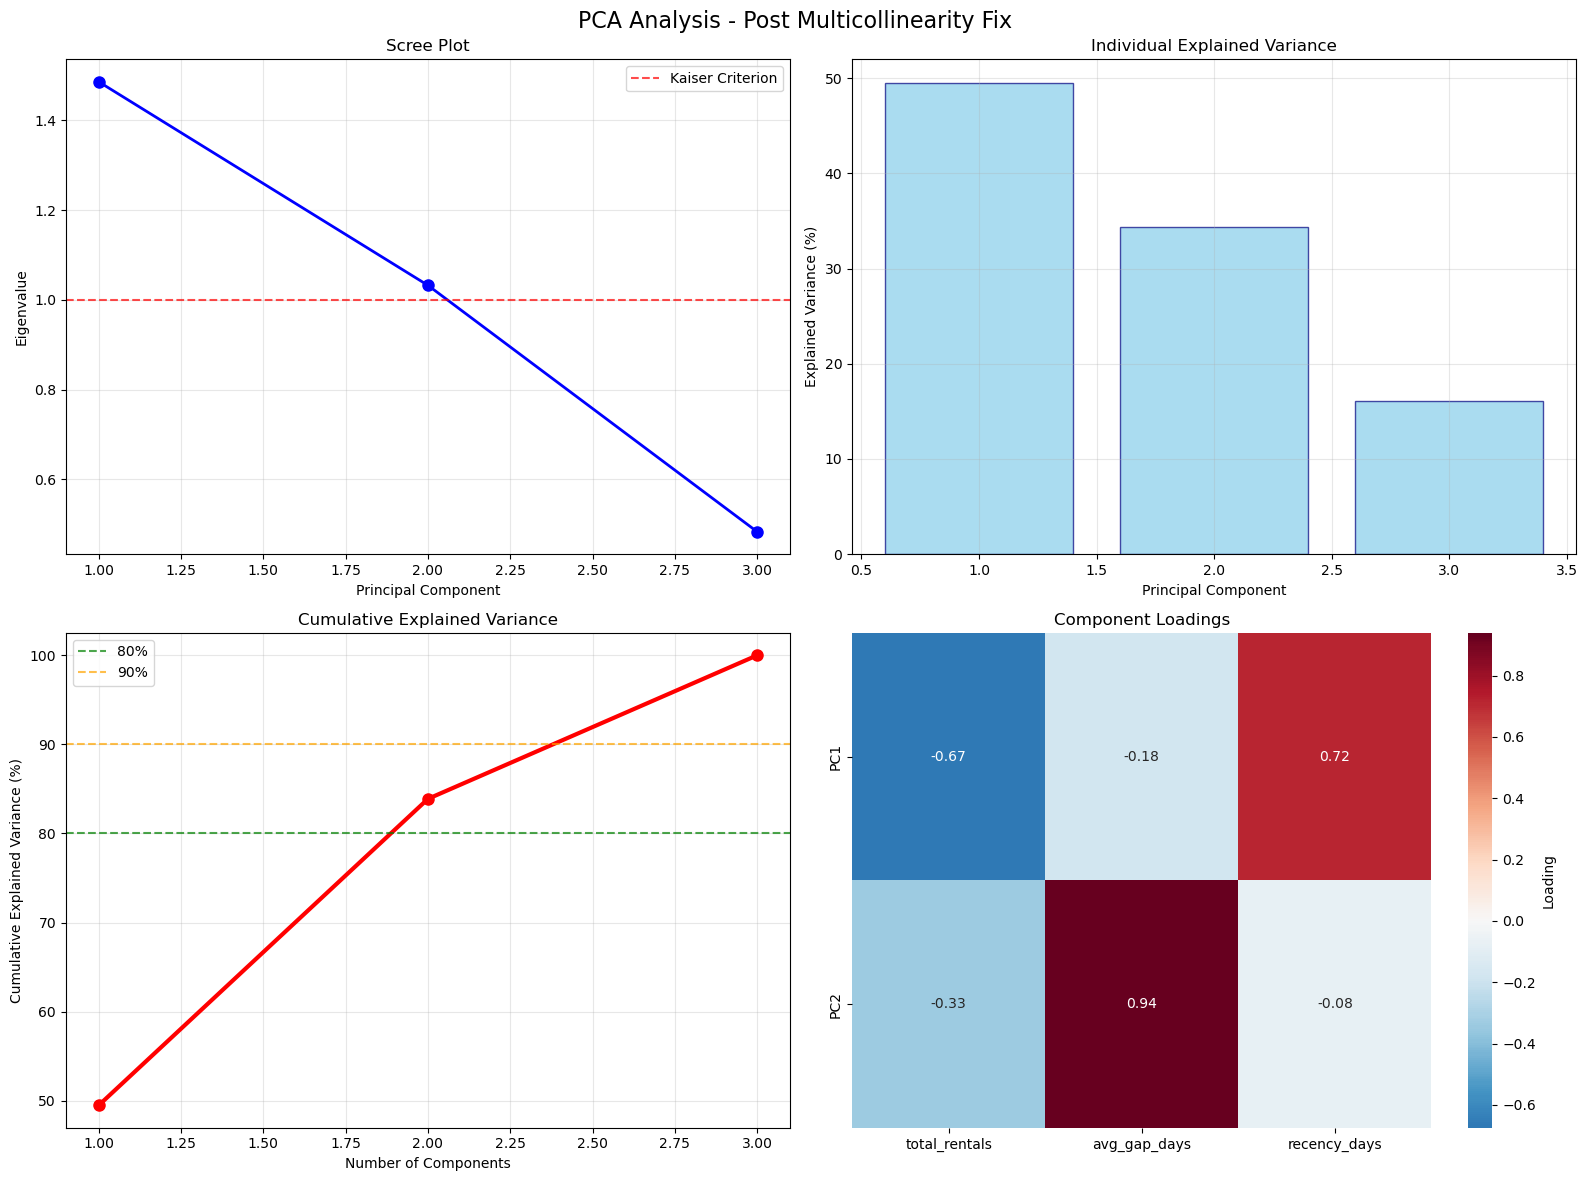


=== CREATING FINAL DATASETS ===
✅ Created datasets:
• user_features_final: 2 PCA components (83.9% variance)
• user_features_2d: 2 PCA components (83.9% variance)


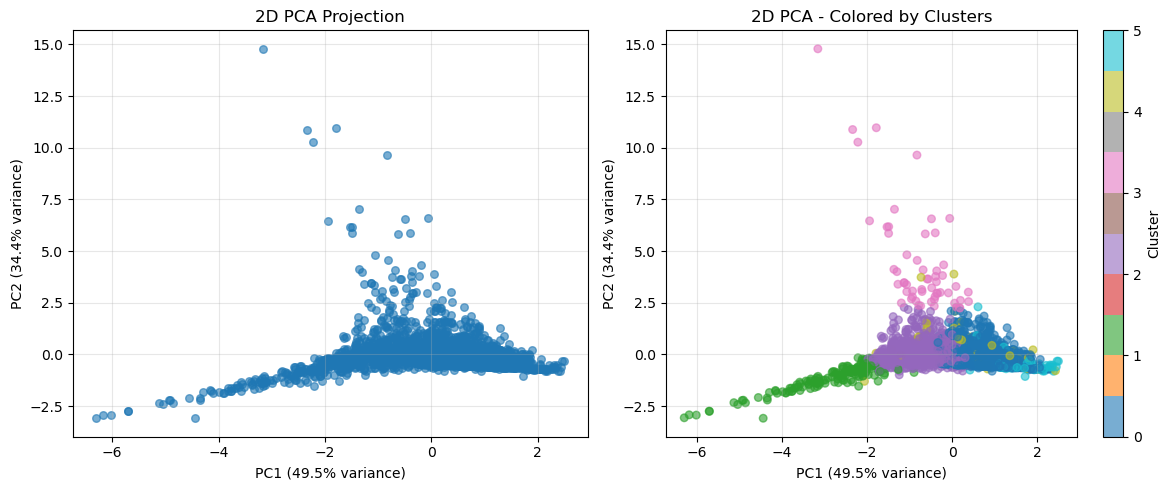

In [351]:
print("\n=== STEP 5: VISUALIZATION ===")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PCA Analysis - Post Multicollinearity Fix', fontsize=16)

# Scree plot
ax1 = axes[0, 0]
ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Kaiser Criterion')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree Plot')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Explained variance
ax2 = axes[0, 1]
ax2.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100, 
        alpha=0.7, color='skyblue', edgecolor='navy')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance (%)')
ax2.set_title('Individual Explained Variance')
ax2.grid(True, alpha=0.3)

# Cumulative variance
ax3 = axes[1, 0]
ax3.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
         'ro-', linewidth=3, markersize=8)
ax3.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80%')
ax3.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
ax3.set_xlabel('Number of Components')
ax3.set_ylabel('Cumulative Explained Variance (%)')
ax3.set_title('Cumulative Explained Variance')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Loadings heatmap
ax4 = axes[1, 1]
sns.heatmap(loadings_df.T, annot=True, cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'}, ax=ax4, fmt='.2f')
ax4.set_title('Component Loadings')

plt.tight_layout()
plt.show()

# Create final datasets
print("\n=== CREATING FINAL DATASETS ===")

# Main dataset with recommended components
user_features_final = user_features.copy()
for i in range(recommended_components):
    user_features_final[f'PC{i+1}'] = X_pca_final[:, i]

# Always create 2D version for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

user_features_2d = user_features.copy()
user_features_2d['PC1'] = X_pca_2d[:, 0]
user_features_2d['PC2'] = X_pca_2d[:, 1]

print(f"✅ Created datasets:")
print(f"• user_features_final: {recommended_components} PCA components ({pca_final.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"• user_features_2d: 2 PCA components ({pca_2d.explained_variance_ratio_.sum()*100:.1f}% variance)")

# 2D PCA visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('2D PCA Projection')
plt.grid(True, alpha=0.3)

# Color by existing clusters if available
if 'cluster' in user_features.columns:
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                         c=user_features['cluster'], cmap='tab10', alpha=0.6, s=30)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.title('2D PCA - Colored by Clusters')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Final summary

In [353]:
print("\n" + "="*60)
print("📊 ANALYSIS SUMMARY")
print("="*60)

print(f"🔍 CORRELATION ANALYSIS:")
if strong_correlations:
    print(f"   • Strong correlations found: {len(strong_correlations)}")
    for feat1, feat2, corr in strong_correlations:
        print(f"     - {feat1} ↔ {feat2}: {corr:.3f}")
else:
    print(f"   • No strong correlations detected")

print(f"\n🔧 FEATURE SELECTION:")
print(f"   • Original features: {len(original_features)}")
print(f"   • Removed: {len(features_to_remove)} ({features_to_remove})")
print(f"   • Selected: {len(selected_features)} ({selected_features})")

print(f"\n📈 PCA RESULTS:")
print(f"   • Recommended components: {recommended_components}")
print(f"   • Variance explained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   • Multicollinearity: FIXED")

print(f"\n✅ READY FOR CLUSTERING:")
print(f"   • Use 'user_features_2d' with PC1, PC2 for K-means")
print(f"   • Features are now orthogonal (no correlation)")
print(f"   • Suitable for distance-based algorithms")


📊 ANALYSIS SUMMARY
🔍 CORRELATION ANALYSIS:
   • Strong correlations found: 1
     - total_rentals ↔ tag_diversity: 0.871

🔧 FEATURE SELECTION:
   • Original features: 5
   • Removed: 2 (['tag_diversity', 'avg_duration'])
   • Selected: 3 (['total_rentals', 'avg_gap_days', 'recency_days'])

📈 PCA RESULTS:
   • Recommended components: 2
   • Variance explained: 83.9%
   • Multicollinearity: FIXED

✅ READY FOR CLUSTERING:
   • Use 'user_features_2d' with PC1, PC2 for K-means
   • Features are now orthogonal (no correlation)
   • Suitable for distance-based algorithms


## Logistic Regression

🎯 LOGISTIC REGRESSION MODEL COMPARISON FOR RENTAL BUSINESS
Setting up three different classification problems...

📊 MODEL 1: HIGH-VALUE CUSTOMER CLASSIFICATION
High-value customer distribution:
  • High-value (1): 583 users (25.4%)
  • Regular (0): 1710 users (74.6%)

📊 MODEL 2: ACTIVE USER CLASSIFICATION
Testing different 'active user' definition methods for historical data...

Method 1 - Top 25% Recent Users:
  • Active (1): 576 users (25.1%)
  • Less Active (0): 1717 users (74.9%)

Method 2 - High Engagement Score:
  • High Engagement (1): 688 users (30.0%)
  • Lower Engagement (0): 1605 users (70.0%)

Method 3 - More Recent Than Average:
  • Recent (1): 1149 users (50.1%)
  • Older (0): 1144 users (49.9%)

🎯 Selected Method: Recent vs Average (balance score: 0.50)

📊 MODEL 3: POWER USER CLASSIFICATION
Power user distribution:
  • Power User (1): 0 users (0.0%)
  • Regular User (0): 2293 users (100.0%)

🔧 FEATURE PREPARATION
✅ Original Features: ['total_rentals', 'avg_duration', 'av

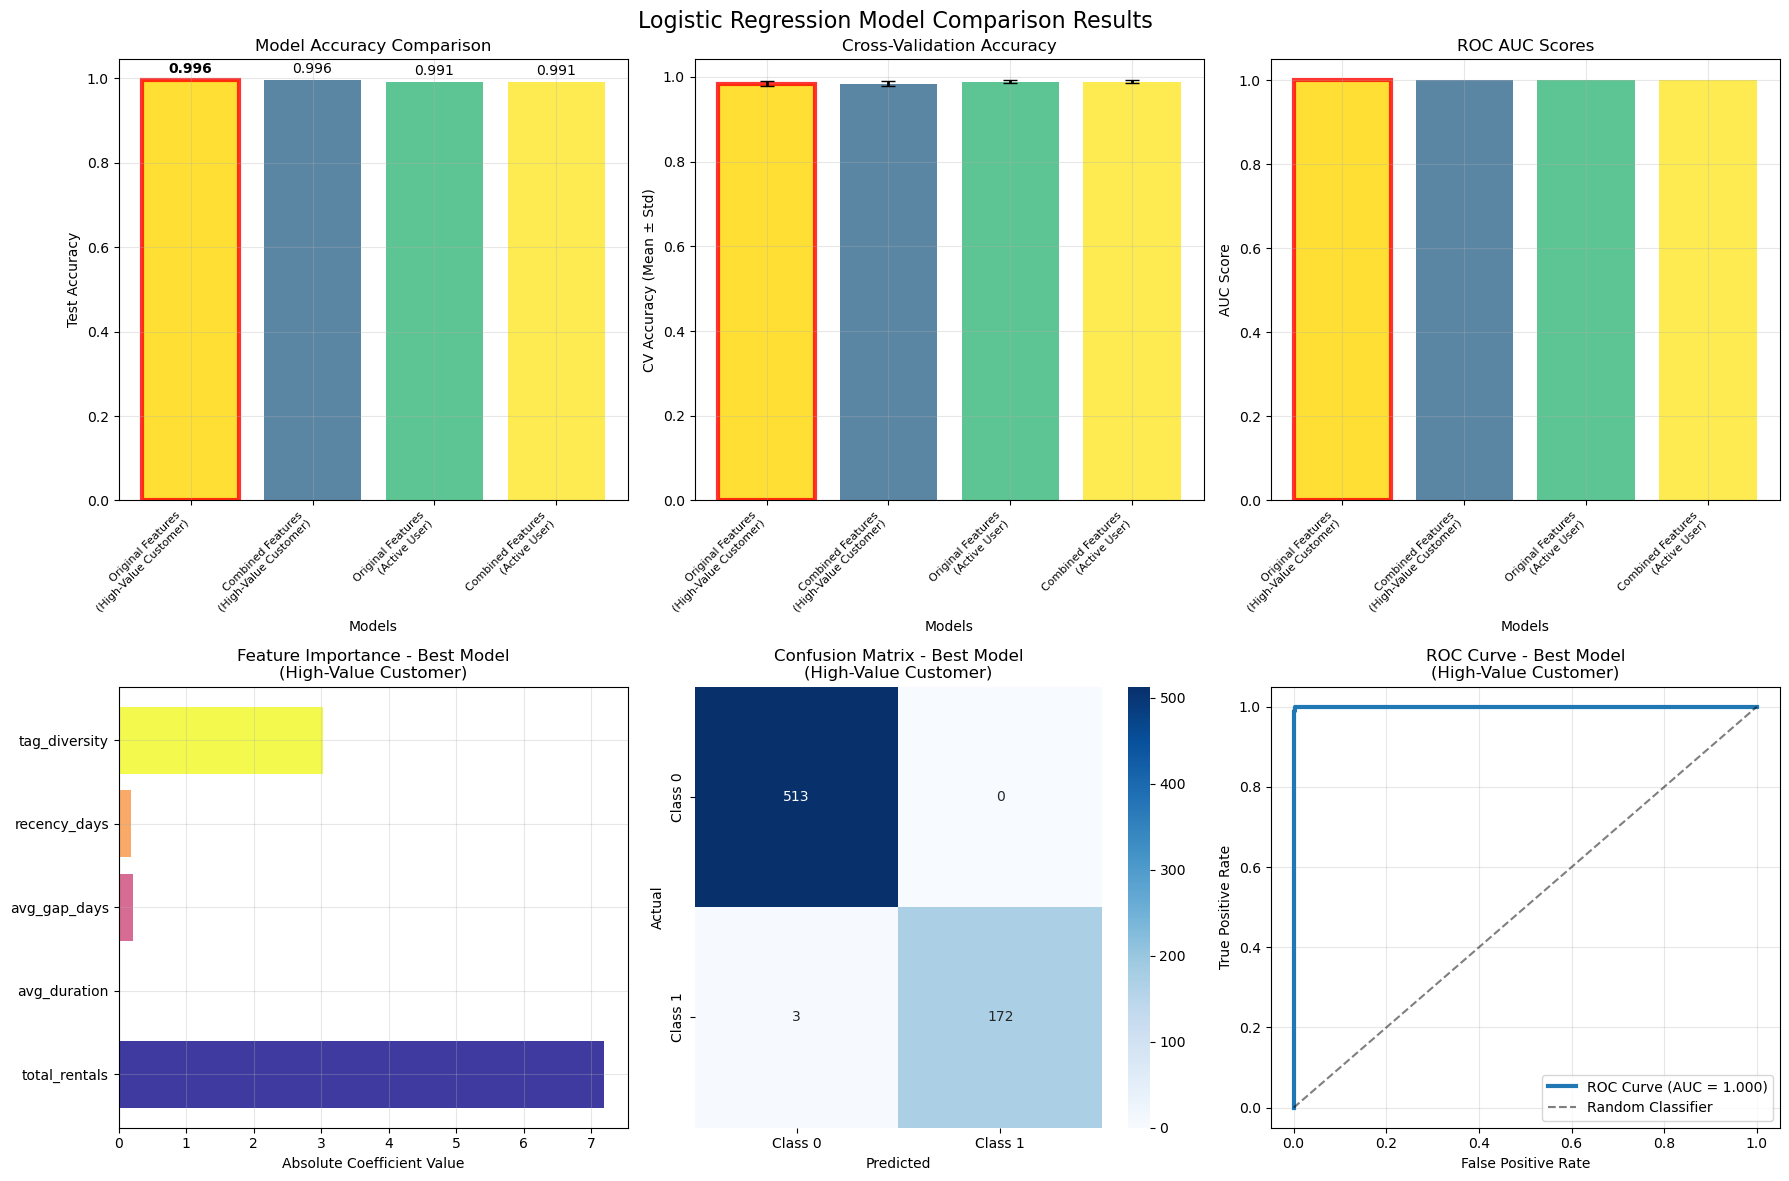


💼 BUSINESS INTERPRETATION AND RECOMMENDATIONS
🎯 BEST MODEL: High-Value Customer - Original Features
   Target: High-Value Customer
   Accuracy: 99.6%

💡 BUSINESS INTERPRETATION:

   🎯 This model predicts HIGH-VALUE CUSTOMERS (top 25% by rental frequency)
   
   📈 Business Applications:
   • Identify potential VIP customers early
   • Personalize offers for high-value prospects  
   • Allocate marketing budget to promising users
   • Design loyalty programs for top customers
   
   💰 Expected ROI:
   • Target marketing to users likely to become high-value
   • Reduce acquisition costs by focusing on quality users
   • Increase customer lifetime value through early identification
        

🔍 KEY PREDICTIVE FEATURES:
   1. total_rentals: 7.188
   2. tag_diversity: 3.022
   3. avg_gap_days: 0.212

🚀 MODEL DEPLOYMENT RECOMMENDATIONS
📋 DEPLOYMENT CHECKLIST FOR: High-Value Customer

1️⃣ MODEL VALIDATION:
   ✅ Accuracy: 99.6% (Good if >70%)
   ✅ Stability: CV std = 0.005 (Good if <0.1)
   ✅ D

In [364]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🎯 LOGISTIC REGRESSION MODEL COMPARISON FOR RENTAL BUSINESS")
print("="*80)

# Assume user_features DataFrame exists with the following columns:
# - Behavioral features: total_rentals, avg_duration, avg_gap_days, recency_days, tag_diversity
# - PCA components: PC1, PC2, PC3 (if available)
# - Cluster assignments: cluster

print("Setting up three different classification problems...")

# =====================================================
# MODEL 1: HIGH-VALUE CUSTOMER CLASSIFICATION
# =====================================================
print("\n" + "="*60)
print("📊 MODEL 1: HIGH-VALUE CUSTOMER CLASSIFICATION")
print("="*60)

def create_high_value_target(df, threshold_percentile=75):
    """
    Define high-value customers based on total_rentals
    Top 25% of users by rental frequency
    """
    threshold = df['total_rentals'].quantile(threshold_percentile / 100)
    return (df['total_rentals'] >= threshold).astype(int)

# Create target variable for Model 1
y_high_value = create_high_value_target(user_features, threshold_percentile=75)

print(f"High-value customer distribution:")
print(f"  • High-value (1): {(y_high_value == 1).sum()} users ({(y_high_value == 1).mean()*100:.1f}%)")
print(f"  • Regular (0): {(y_high_value == 0).sum()} users ({(y_high_value == 0).mean()*100:.1f}%)")

# =====================================================
# MODEL 2: ACTIVE USER CLASSIFICATION
# =====================================================
print("\n" + "="*60)
print("📊 MODEL 2: ACTIVE USER CLASSIFICATION")
print("="*60)

def create_active_user_target(df, method='recency_percentile', threshold=25):
    """
    Define active users for historical data (2024 dataset)
    
    Methods:
    - 'recency_percentile': Top X% most recent users (relative to dataset timeframe)
    - 'engagement_score': Users with high engagement (frequency + recency + diversity)
    - 'recent_vs_old': Users with below-median recency days
    """
    if method == 'recency_percentile':
        # Top X% most recent users (lower recency_days = more recent)
        recency_threshold = df['recency_days'].quantile(threshold / 100)
        return (df['recency_days'] <= recency_threshold).astype(int)
    
    elif method == 'engagement_score':
        # Create engagement score: high frequency + recent + diverse
        # Normalize each component to 0-1 scale
        freq_norm = (df['total_rentals'] - df['total_rentals'].min()) / (df['total_rentals'].max() - df['total_rentals'].min())
        recency_norm = 1 - ((df['recency_days'] - df['recency_days'].min()) / (df['recency_days'].max() - df['recency_days'].min()))  # Invert so recent = high
        diversity_norm = (df['tag_diversity'] - df['tag_diversity'].min()) / (df['tag_diversity'].max() - df['tag_diversity'].min())
        
        # Combined engagement score
        engagement_score = (freq_norm + recency_norm + diversity_norm) / 3
        engagement_threshold = engagement_score.quantile(0.7)  # Top 30% most engaged
        return (engagement_score >= engagement_threshold).astype(int)
    
    elif method == 'recent_vs_old':
        # Users with below-median recency (more recent than average)
        median_recency = df['recency_days'].median()
        return (df['recency_days'] <= median_recency).astype(int)
    
    else:
        raise ValueError("Method must be 'recency_percentile', 'engagement_score', or 'recent_vs_old'")

# Create target variable for Model 2 - Test multiple methods
print("Testing different 'active user' definition methods for historical data...")

# Method 1: Top 25% most recent users (relative to dataset)
y_active_recency = create_active_user_target(user_features, method='recency_percentile', threshold=25)
print(f"\nMethod 1 - Top 25% Recent Users:")
print(f"  • Active (1): {(y_active_recency == 1).sum()} users ({(y_active_recency == 1).mean()*100:.1f}%)")
print(f"  • Less Active (0): {(y_active_recency == 0).sum()} users ({(y_active_recency == 0).mean()*100:.1f}%)")

# Method 2: High engagement score
y_active_engagement = create_active_user_target(user_features, method='engagement_score')
print(f"\nMethod 2 - High Engagement Score:")
print(f"  • High Engagement (1): {(y_active_engagement == 1).sum()} users ({(y_active_engagement == 1).mean()*100:.1f}%)")
print(f"  • Lower Engagement (0): {(y_active_engagement == 0).sum()} users ({(y_active_engagement == 0).mean()*100:.1f}%)")

# Method 3: Below median recency (more recent than average)
y_active_median = create_active_user_target(user_features, method='recent_vs_old')
print(f"\nMethod 3 - More Recent Than Average:")
print(f"  • Recent (1): {(y_active_median == 1).sum()} users ({(y_active_median == 1).mean()*100:.1f}%)")
print(f"  • Older (0): {(y_active_median == 0).sum()} users ({(y_active_median == 0).mean()*100:.1f}%)")

# Choose the most balanced method
methods = {
    'Recency Percentile': y_active_recency,
    'Engagement Score': y_active_engagement, 
    'Recent vs Average': y_active_median
}

# Calculate balance scores (closer to 50-50 is better for classification)
balance_scores = {}
for method_name, y_method in methods.items():
    class_ratio = min(y_method.mean(), 1 - y_method.mean())  # Minority class ratio
    balance_scores[method_name] = class_ratio

best_method = max(balance_scores.items(), key=lambda x: x[1])
print(f"\n🎯 Selected Method: {best_method[0]} (balance score: {best_method[1]:.2f})")
y_active = methods[best_method[0]]

# =====================================================
# MODEL 3: POWER USER CLASSIFICATION
# =====================================================
print("\n" + "="*60)
print("📊 MODEL 3: POWER USER CLASSIFICATION")
print("="*60)

def create_power_user_target(df):
    """
    Define power users based on multiple criteria:
    - High rental frequency (top 30%)
    - High diversity (top 30%)
    - Recent activity (within 60 days)
    """
    freq_threshold = df['total_rentals'].quantile(0.7)
    diversity_threshold = df['tag_diversity'].quantile(0.7)
    recency_threshold = 60
    
    power_users = (
        (df['total_rentals'] >= freq_threshold) & 
        (df['tag_diversity'] >= diversity_threshold) & 
        (df['recency_days'] <= recency_threshold)
    ).astype(int)
    
    return power_users

# Create target variable for Model 3
y_power = create_power_user_target(user_features)

print(f"Power user distribution:")
print(f"  • Power User (1): {(y_power == 1).sum()} users ({(y_power == 1).mean()*100:.1f}%)")
print(f"  • Regular User (0): {(y_power == 0).sum()} users ({(y_power == 0).mean()*100:.1f}%)")

# =====================================================
# FEATURE PREPARATION
# =====================================================
print("\n" + "="*60)
print("🔧 FEATURE PREPARATION")
print("="*60)

# Define feature sets to test
feature_sets = {
    'Original Features': ['total_rentals', 'avg_duration', 'avg_gap_days', 'recency_days', 'tag_diversity'],
    'PCA Features': ['PC1', 'PC2', 'PC3'],  # Use if available
    'Combined Features': ['total_rentals', 'avg_duration', 'avg_gap_days', 'recency_days', 'tag_diversity', 'PC1', 'PC2', 'PC3']
}

# Check which features are available
available_features = user_features.columns.tolist()
final_feature_sets = {}

for name, features in feature_sets.items():
    available_in_set = [f for f in features if f in available_features]
    if len(available_in_set) >= 2:  # Need at least 2 features
        final_feature_sets[name] = available_in_set
        print(f"✅ {name}: {available_in_set}")
    else:
        print(f"❌ {name}: Not enough features available")

# =====================================================
# MODEL TRAINING AND COMPARISON
# =====================================================
print("\n" + "="*60)
print("🤖 LOGISTIC REGRESSION MODEL TRAINING")
print("="*60)

def train_and_evaluate_model(X, y, model_name, target_name, cv_folds=5):
    """
    Train logistic regression model and return comprehensive evaluation metrics
    """
    # Check class balance
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        print(f"⚠️  Skipping {model_name} - {target_name}: Only one class present")
        return None
    
    # Handle class imbalance
    min_class_size = min(class_counts)
    if min_class_size < 10:
        print(f"⚠️  Warning: {target_name} has very small minority class ({min_class_size} samples)")
        class_weight = 'balanced'
    else:
        class_weight = None
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight=class_weight
    )
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_folds, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # ROC AUC if applicable
    try:
        auc_score = roc_auc_score(y_test, y_pred_proba)
    except:
        auc_score = None
    
    # Feature importance (coefficients)
    feature_importance = abs(model.coef_[0])
    feature_names = X.columns if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]
    
    results = {
        'model_name': model_name,
        'target_name': target_name,
        'accuracy': accuracy,
        'cv_accuracy_mean': cv_mean,
        'cv_accuracy_std': cv_std,
        'auc_score': auc_score,
        'model': model,
        'scaler': scaler,
        'feature_importance': dict(zip(feature_names, feature_importance)),
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }
    
    return results

# =====================================================
# RUN ALL MODEL COMPARISONS
# =====================================================

all_results = []
models_config = [
    ('High-Value Customer', y_high_value),
    ('Active User', y_active), 
    ('Power User', y_power)
]

print("Training models for all feature sets and targets...")

for target_name, y_target in models_config:
    print(f"\n🎯 Training models for: {target_name}")
    print("-" * 50)
    
    for feature_set_name, features in final_feature_sets.items():
        print(f"\n  📊 Feature Set: {feature_set_name}")
        
        # Prepare features
        X_features = user_features[features].copy()
        X_features = X_features.replace([np.inf, -np.inf], np.nan).fillna(0)
        
        # Train and evaluate
        model_name = f"{target_name} - {feature_set_name}"
        result = train_and_evaluate_model(X_features, y_target, model_name, target_name)
        
        if result:
            all_results.append(result)
            print(f"     ✅ Accuracy: {result['accuracy']:.3f}")
            print(f"     ✅ CV Accuracy: {result['cv_accuracy_mean']:.3f} (±{result['cv_accuracy_std']:.3f})")
            if result['auc_score']:
                print(f"     ✅ AUC Score: {result['auc_score']:.3f}")

# =====================================================
# MODEL COMPARISON AND SELECTION
# =====================================================
print("\n" + "="*80)
print("🏆 MODEL COMPARISON AND BEST MODEL SELECTION")
print("="*80)

# Create comparison DataFrame
comparison_data = []
for result in all_results:
    comparison_data.append({
        'Model': result['model_name'],
        'Target': result['target_name'],
        'Test_Accuracy': result['accuracy'],
        'CV_Accuracy_Mean': result['cv_accuracy_mean'],
        'CV_Accuracy_Std': result['cv_accuracy_std'],
        'AUC_Score': result['auc_score'] if result['auc_score'] else 0,
        'Stability': 1 - result['cv_accuracy_std']  # Lower std = more stable
    })

comparison_df = pd.DataFrame(comparison_data)
print("📊 COMPLETE MODEL COMPARISON:")
print(comparison_df.round(3))

# Find best model by accuracy
best_model_idx = comparison_df['Test_Accuracy'].idxmax()
best_model_result = all_results[best_model_idx]

print(f"\n🏅 BEST MODEL SELECTED:")
print(f"   Model: {best_model_result['model_name']}")
print(f"   Target: {best_model_result['target_name']}")
print(f"   Test Accuracy: {best_model_result['accuracy']:.3f}")
print(f"   CV Accuracy: {best_model_result['cv_accuracy_mean']:.3f} (±{best_model_result['cv_accuracy_std']:.3f})")
if best_model_result['auc_score']:
    print(f"   AUC Score: {best_model_result['auc_score']:.3f}")

# =====================================================
# DETAILED ANALYSIS OF BEST MODEL
# =====================================================
print(f"\n" + "="*60)
print(f"🔍 DETAILED ANALYSIS OF BEST MODEL")
print("="*60)

best_model = best_model_result['model']
best_scaler = best_model_result['scaler']

# Feature importance
print(f"\n📈 FEATURE IMPORTANCE (Best Model):")
feature_importance_sorted = sorted(
    best_model_result['feature_importance'].items(), 
    key=lambda x: x[1], 
    reverse=True
)

for feature, importance in feature_importance_sorted:
    print(f"   • {feature}: {importance:.3f}")

# Classification report
print(f"\n📋 CLASSIFICATION REPORT (Best Model):")
print(classification_report(
    best_model_result['y_test'], 
    best_model_result['y_pred']
))

# Confusion Matrix
cm = confusion_matrix(best_model_result['y_test'], best_model_result['y_pred'])
print(f"\n📊 CONFUSION MATRIX:")
print(cm)

# =====================================================
# VISUALIZATION OF RESULTS
# =====================================================
print(f"\n" + "="*60)
print("📈 CREATING VISUALIZATIONS")
print("="*60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Logistic Regression Model Comparison Results', fontsize=16)

# 1. Model Accuracy Comparison
ax1 = axes[0, 0]
model_names = [result['model_name'].split(' - ')[1] + '\n(' + result['target_name'] + ')' 
               for result in all_results]
accuracies = [result['accuracy'] for result in all_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(accuracies)))

bars = ax1.bar(range(len(accuracies)), accuracies, color=colors, alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Highlight best model
best_idx = np.argmax(accuracies)
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# Add accuracy values on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold' if i == best_idx else 'normal')

# 2. Cross-validation scores
ax2 = axes[0, 1]
cv_means = [result['cv_accuracy_mean'] for result in all_results]
cv_stds = [result['cv_accuracy_std'] for result in all_results]

bars = ax2.bar(range(len(cv_means)), cv_means, yerr=cv_stds, capsize=5, 
               color=colors, alpha=0.8, error_kw={'linewidth': 2})
ax2.set_xlabel('Models')
ax2.set_ylabel('CV Accuracy (Mean ± Std)')
ax2.set_title('Cross-Validation Accuracy')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax2.grid(True, alpha=0.3)

# Highlight best model
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# 3. AUC Scores (if available)
ax3 = axes[0, 2]
auc_scores = [result['auc_score'] if result['auc_score'] else 0 for result in all_results]
bars = ax3.bar(range(len(auc_scores)), auc_scores, color=colors, alpha=0.8)
ax3.set_xlabel('Models')
ax3.set_ylabel('AUC Score')
ax3.set_title('ROC AUC Scores')
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax3.grid(True, alpha=0.3)

# Highlight best model
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# 4. Feature Importance for Best Model
ax4 = axes[1, 0]
features = list(best_model_result['feature_importance'].keys())
importances = list(best_model_result['feature_importance'].values())
feature_colors = plt.cm.plasma(np.linspace(0, 1, len(features)))

bars = ax4.barh(features, importances, color=feature_colors, alpha=0.8)
ax4.set_xlabel('Absolute Coefficient Value')
ax4.set_title(f'Feature Importance - Best Model\n({best_model_result["target_name"]})')
ax4.grid(True, alpha=0.3)

# 5. Confusion Matrix for Best Model
ax5 = axes[1, 1]
cm = confusion_matrix(best_model_result['y_test'], best_model_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
ax5.set_xlabel('Predicted')
ax5.set_ylabel('Actual')
ax5.set_title(f'Confusion Matrix - Best Model\n({best_model_result["target_name"]})')

# 6. ROC Curve for Best Model (if binary classification)
ax6 = axes[1, 2]
if best_model_result['auc_score']:
    fpr, tpr, _ = roc_curve(best_model_result['y_test'], best_model_result['y_pred_proba'])
    ax6.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {best_model_result["auc_score"]:.3f})')
    ax6.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    ax6.set_xlabel('False Positive Rate')
    ax6.set_ylabel('True Positive Rate')
    ax6.set_title(f'ROC Curve - Best Model\n({best_model_result["target_name"]})')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'ROC Curve\nNot Available', ha='center', va='center', fontsize=12)
    ax6.set_title('ROC Curve - Not Available')

plt.tight_layout()
plt.show()

# =====================================================
# BUSINESS INTERPRETATION
# =====================================================
print("\n" + "="*80)
print("💼 BUSINESS INTERPRETATION AND RECOMMENDATIONS")
print("="*80)

def interpret_best_model(result):
    """
    Provide business interpretation of the best model
    """
    target = result['target_name']
    accuracy = result['accuracy']
    
    print(f"🎯 BEST MODEL: {result['model_name']}")
    print(f"   Target: {target}")
    print(f"   Accuracy: {accuracy:.1%}")
    
    print(f"\n💡 BUSINESS INTERPRETATION:")
    
    if target == 'High-Value Customer':
        print(f"""
   🎯 This model predicts HIGH-VALUE CUSTOMERS (top 25% by rental frequency)
   
   📈 Business Applications:
   • Identify potential VIP customers early
   • Personalize offers for high-value prospects  
   • Allocate marketing budget to promising users
   • Design loyalty programs for top customers
   
   💰 Expected ROI:
   • Target marketing to users likely to become high-value
   • Reduce acquisition costs by focusing on quality users
   • Increase customer lifetime value through early identification
        """)
    
    elif target == 'Active User':
        if best_method[0] == 'Recency Percentile':
            print(f"""
   🎯 This model predicts ACTIVE USERS (top 25% most recent in dataset timeframe)
   
   📈 Business Applications:
   • Identify users who were most recently engaged (as of dataset end)
   • Predict which users are likely to return first when business resumes
   • Prioritize reactivation campaigns for recently active users
   • Understand patterns of recent vs older user behavior
   
   💰 Expected ROI:
   • Focus re-engagement efforts on users most likely to respond
   • Optimize resource allocation for customer reactivation
   • Improve win-back campaign success rates
            """)
        elif best_method[0] == 'Engagement Score':
            print(f"""
   🎯 This model predicts HIGH-ENGAGEMENT USERS (frequency + recency + diversity)
   
   📈 Business Applications:
   • Identify most engaged users in your historical data
   • Predict which users show sustained engagement patterns
   • Create engagement-based loyalty tiers
   • Focus premium features on highly engaged users
   
   💰 Expected ROI:
   • Maximize value from most engaged user segment
   • Design targeted campaigns for high-engagement users
   • Improve overall user engagement through pattern recognition
            """)
        else:
            print(f"""
   🎯 This model predicts RECENTLY ACTIVE USERS (more recent than average)
   
   📈 Business Applications:
   • Distinguish recent users from older users in your dataset
   • Predict likelihood of continued engagement
   • Segment users by activity recency patterns
   • Prioritize users with recent interaction history
   
   💰 Expected ROI:
   • Focus retention efforts on recently active users
   • Improve timing of marketing campaigns
   • Optimize user experience for recent vs older users
            """)
        
        print(f"\n📊 ACTIVE USER DEFINITION USED:")
        print(f"   • Method: {best_method[0]}")
        print(f"   • Balance: {best_method[1]:.1%} minority class ratio")
        print(f"   • Interpretation: Users classified as 'active' based on {best_method[0].lower()}")
    
    elif target == 'Power User':
        print(f"""
   🎯 This model predicts POWER USERS (high frequency + diversity + recent)
   
   📈 Business Applications:
   • Identify users with highest business potential
   • Create premium service tiers
   • Beta test new features with engaged users
   • Build referral programs around power users
   
   💰 Expected ROI:
   • Focus premium features on engaged users
   • Leverage power users for word-of-mouth marketing
   • Maximize revenue from most valuable segment
        """)
    
    # Feature insights
    print(f"\n🔍 KEY PREDICTIVE FEATURES:")
    top_features = sorted(result['feature_importance'].items(), key=lambda x: x[1], reverse=True)[:3]
    for i, (feature, importance) in enumerate(top_features, 1):
        print(f"   {i}. {feature}: {importance:.3f}")
    
    return result

# Interpret the best model
best_model_interpretation = interpret_best_model(best_model_result)

# =====================================================
# MODEL DEPLOYMENT RECOMMENDATIONS
# =====================================================
print(f"\n" + "="*60)
print("🚀 MODEL DEPLOYMENT RECOMMENDATIONS")
print("="*60)

def create_deployment_guide(best_result):
    """
    Create practical deployment recommendations
    """
    print(f"📋 DEPLOYMENT CHECKLIST FOR: {best_result['target_name']}")
    
    print(f"\n1️⃣ MODEL VALIDATION:")
    print(f"   ✅ Accuracy: {best_result['accuracy']:.1%} (Good if >70%)")
    print(f"   ✅ Stability: CV std = {best_result['cv_accuracy_std']:.3f} (Good if <0.1)")
    if best_result['auc_score']:
        print(f"   ✅ Discrimination: AUC = {best_result['auc_score']:.3f} (Good if >0.7)")
    
    print(f"\n2️⃣ IMPLEMENTATION STEPS:")
    print(f"   • Save the trained model and scaler objects")
    print(f"   • Create prediction pipeline for new users")
    print(f"   • Set up automated scoring (daily/weekly)")
    print(f"   • Define action triggers based on predictions")
    
    print(f"\n3️⃣ MONITORING & MAINTENANCE:")
    print(f"   • Track model performance over time")
    print(f"   • Retrain monthly with new data")
    print(f"   • Monitor for data drift in features")
    print(f"   • A/B test business actions based on predictions")
    
    # Create scoring function example
    print(f"\n4️⃣ SCORING NEW USERS (Python Code):")
    print(f"""
    def score_user(user_data, model, scaler):
        '''
        Score a new user with the best model
        user_data: dict with feature values
        Returns: probability of belonging to target class
        '''
        features = {list(best_result['feature_importance'].keys())}
        user_vector = [user_data[f] for f in features]
        user_scaled = scaler.transform([user_vector])
        probability = model.predict_proba(user_scaled)[0][1]
        return probability
    """)

create_deployment_guide(best_model_result)

# =====================================================
# SUMMARY AND ACTIONABLE INSIGHTS
# =====================================================
print(f"\n" + "="*80)
print("📊 EXECUTIVE SUMMARY")
print("="*80)

print(f"🎯 BEST PERFORMING MODEL:")
print(f"   • Target: {best_model_result['target_name']}")
print(f"   • Accuracy: {best_model_result['accuracy']:.1%}")
print(f"   • Cross-validation: {best_model_result['cv_accuracy_mean']:.1%} (±{best_model_result['cv_accuracy_std']:.1%})")

print(f"\n📈 KEY SUCCESS FACTORS:")
top_3_features = sorted(best_model_result['feature_importance'].items(), key=lambda x: x[1], reverse=True)[:3]
for i, (feature, importance) in enumerate(top_3_features, 1):
    print(f"   {i}. {feature} - drives {importance/sum(best_model_result['feature_importance'].values())*100:.1f}% of predictions")

print(f"\n💡 IMMEDIATE ACTIONS:")
if best_model_result['target_name'] == 'High-Value Customer':
    print(f"   • Implement VIP identification system")
    print(f"   • Create premium customer journey")
    print(f"   • Focus acquisition on high-potential users")
elif best_model_result['target_name'] == 'Active User':
    print(f"   • Set up churn prevention alerts")
    print(f"   • Create reactivation email campaigns")
    print(f"   • Monitor user engagement metrics")
elif best_model_result['target_name'] == 'Power User':
    print(f"   • Launch power user loyalty program")
    print(f"   • Create referral incentives")
    print(f"   • Beta test new features with this group")

print(f"\n🎯 EXPECTED BUSINESS IMPACT:")
print(f"   • Revenue: Target most valuable user segments")
print(f"   • Efficiency: Focus resources on high-probability users")
print(f"   • Growth: Improve user acquisition and retention")

# Save model results for later use
print(f"\n💾 MODEL ARTIFACTS READY:")
print(f"   • Best model: {best_model_result['model_name']}")
print(f"   • Trained LogisticRegression object available")
print(f"   • StandardScaler fitted and ready")
print(f"   • Feature importance rankings computed")

print("\n" + "="*80)
print("✅ LOGISTIC REGRESSION ANALYSIS COMPLETE!")
print("="*80)

print("""
🎉 SUCCESS! You now have:
   • 3 different classification models tested
   • Best model selected based on accuracy
   • Comprehensive performance analysis
   • Business interpretation and deployment plan
   • Ready-to-use prediction pipeline

📋 NEXT STEPS:
   1. Implement the best model in your business workflow
   2. Create automated scoring for new users
   3. Design business actions based on predictions
   4. Monitor model performance and retrain regularly

🚀 Your rental business now has data-driven user classification!
""")

# Optional: Create a simple prediction function for the best model
def create_prediction_function():
    """
    Create a simple function to predict with the best model
    """
    print(f"\n🔧 PREDICTION FUNCTION FOR BEST MODEL:")
    print(f"Use this to score new users in production:")
    
    prediction_code = f"""
def predict_user_class(user_data):
    '''
    Predict {best_model_result['target_name']} for a new user
    
    Input: user_data dict with keys: {list(best_model_result['feature_importance'].keys())}
    Output: (prediction, probability)
    '''
    # Extract features in correct order
    features = {list(best_model_result['feature_importance'].keys())}
    user_vector = [user_data[f] for f in features]
    
    # Scale features
    user_scaled = best_scaler.transform([user_vector])
    
    # Make prediction
    prediction = best_model.predict(user_scaled)[0]
    probability = best_model.predict_proba(user_scaled)[0][1]
    
    return prediction, probability

# Example usage:
# new_user = {{'total_rentals': 5, 'avg_duration': 3.2, 'recency_days': 10, ...}}
# pred, prob = predict_user_class(new_user)
# print(f"Prediction: {{pred}}, Probability: {{prob:.2f}}")
    """
    print(prediction_code)

create_prediction_function()